In [10]:
# import the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

# Fine-tune globally
plt.rcParams.update({
    'figure.figsize'  : (10, 6),
    'axes.titlesize'  : 14,
    'axes.labelsize'  : 12,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
    'figure.dpi'      : 120,       # crisp in notebooks
    'font.family'     : 'DejaVu Sans',
})

In [6]:
df = pd.read_csv('concrete_data.csv')

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
# --- Look at the data
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB
None


- No null values in the data

In [7]:
df.describe().round(2)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.35,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.80,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.40,968.00,779.50,28.00,34.44
75%,350.00,142.95,118.30,192.00,10.20,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60


- Just a small idea about the numeric columns 

- All the columns are numeric Type 

### ***Univariate Analysis***

In [8]:
# Let me quickly split the Features and Output Seperately
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

print(X.shape)
print(y.shape)

(1030, 8)
(1030,)


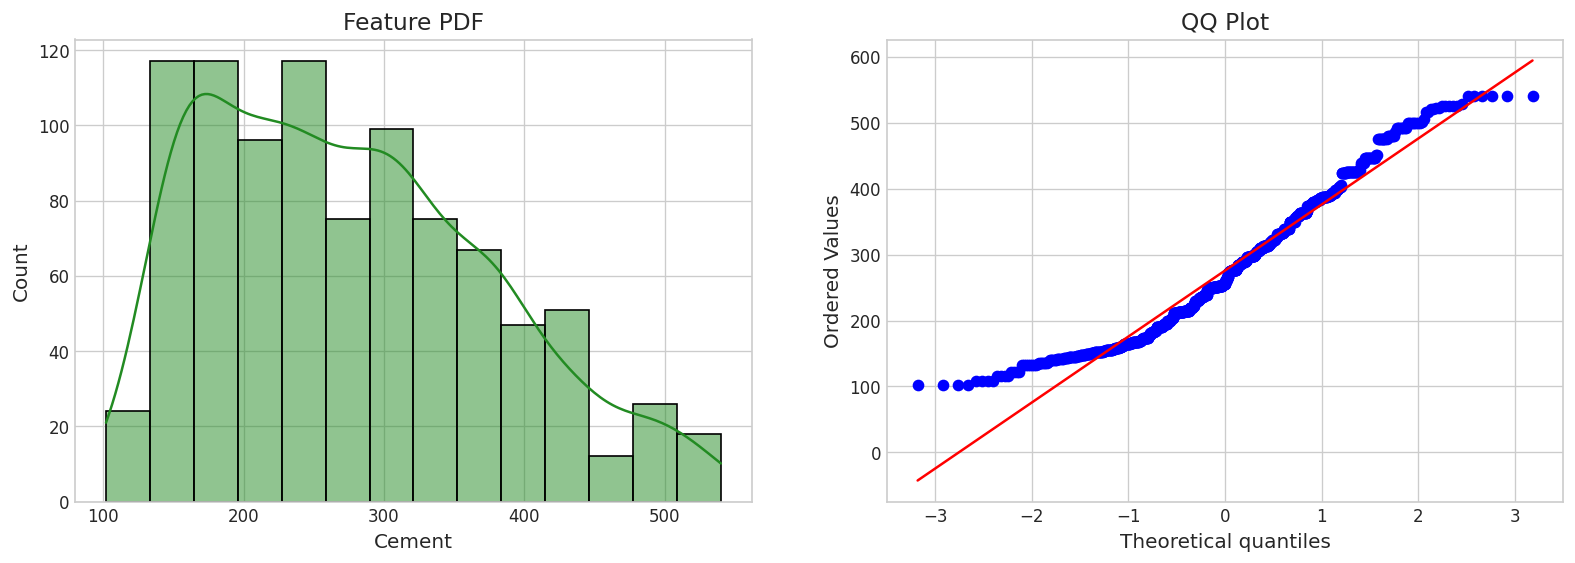

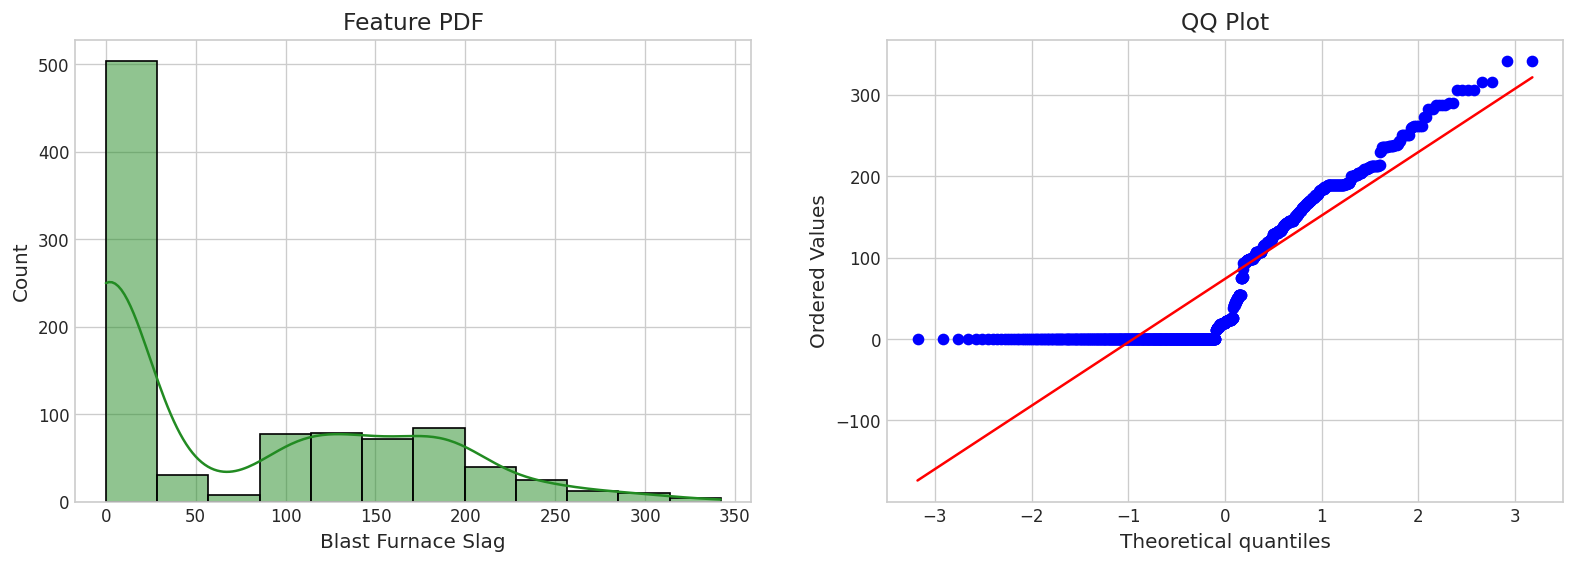

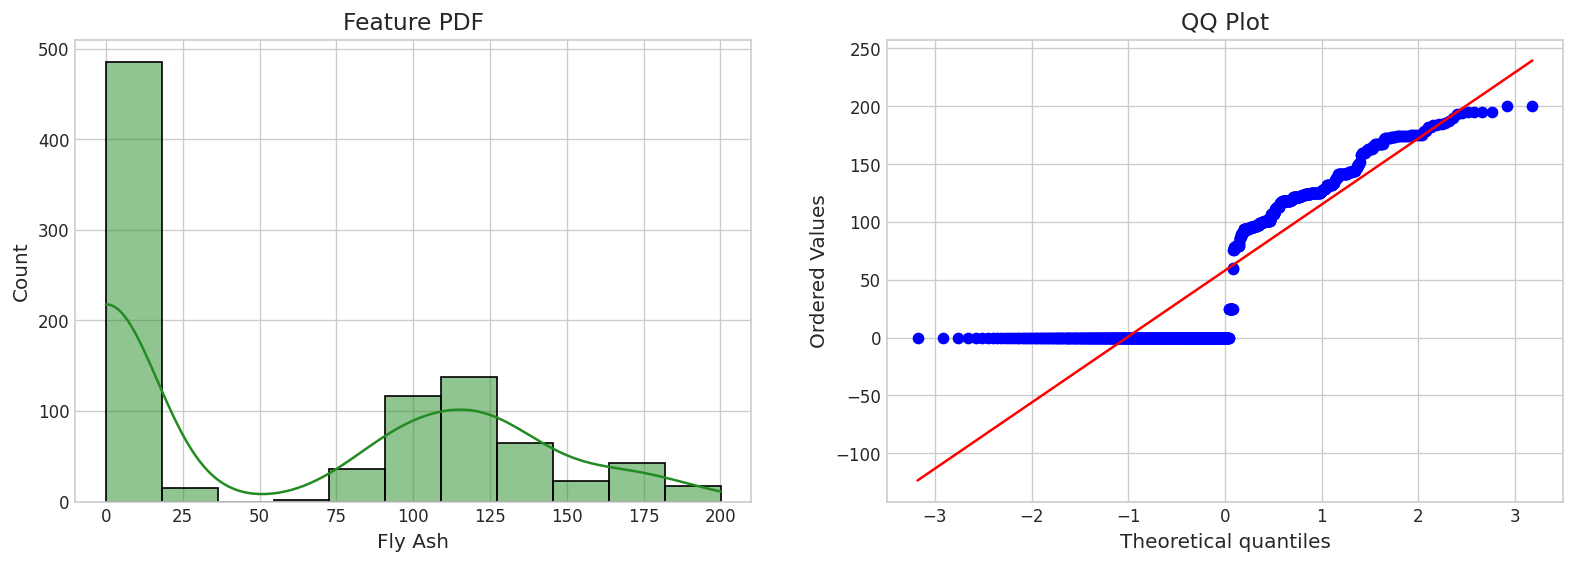

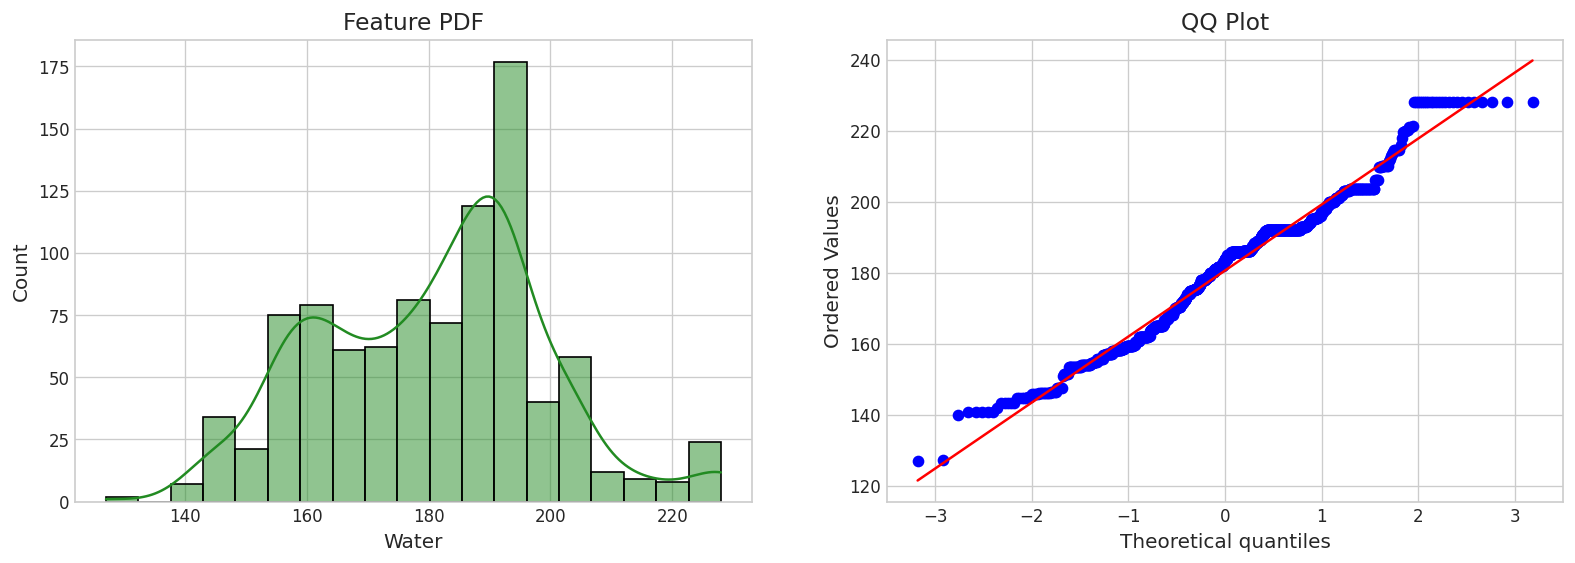

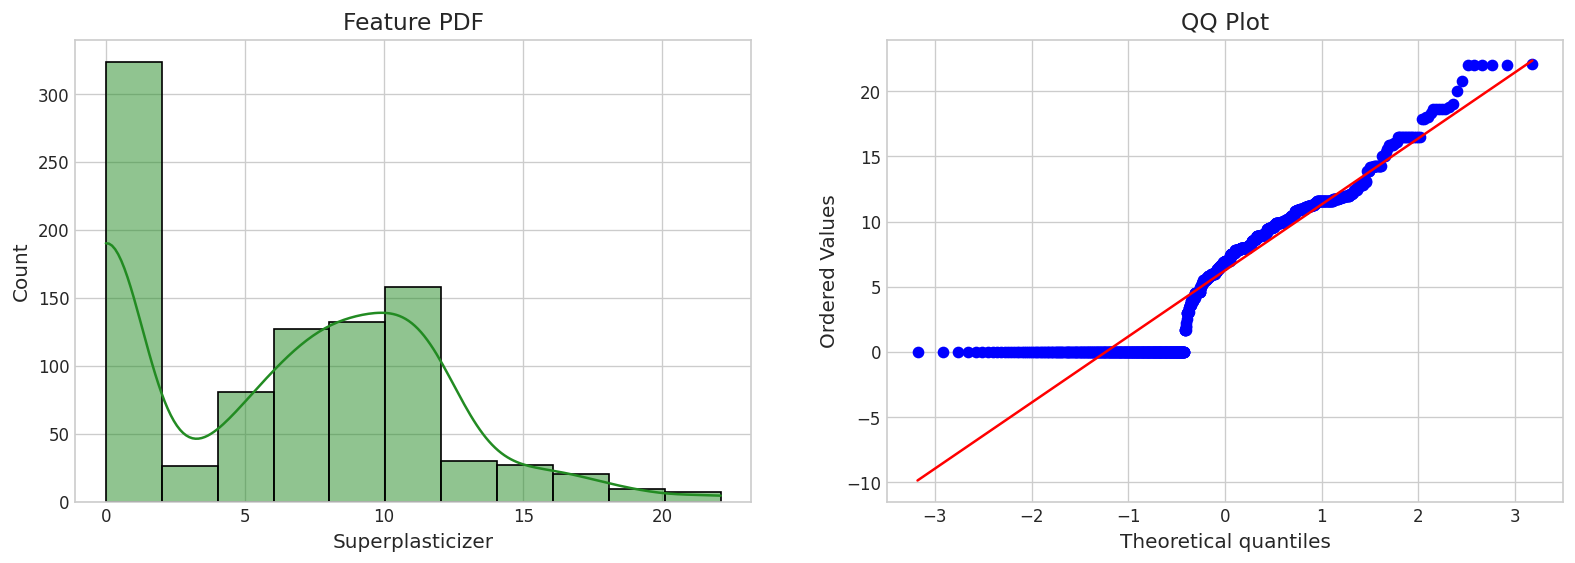

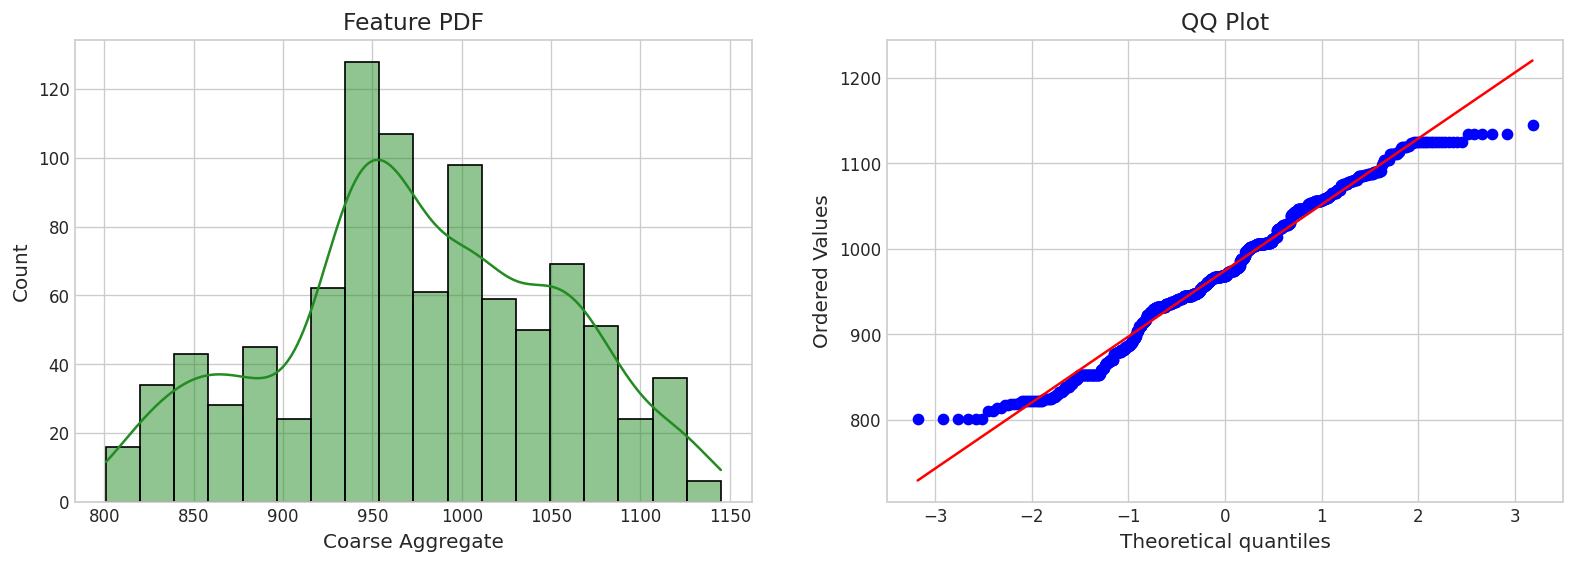

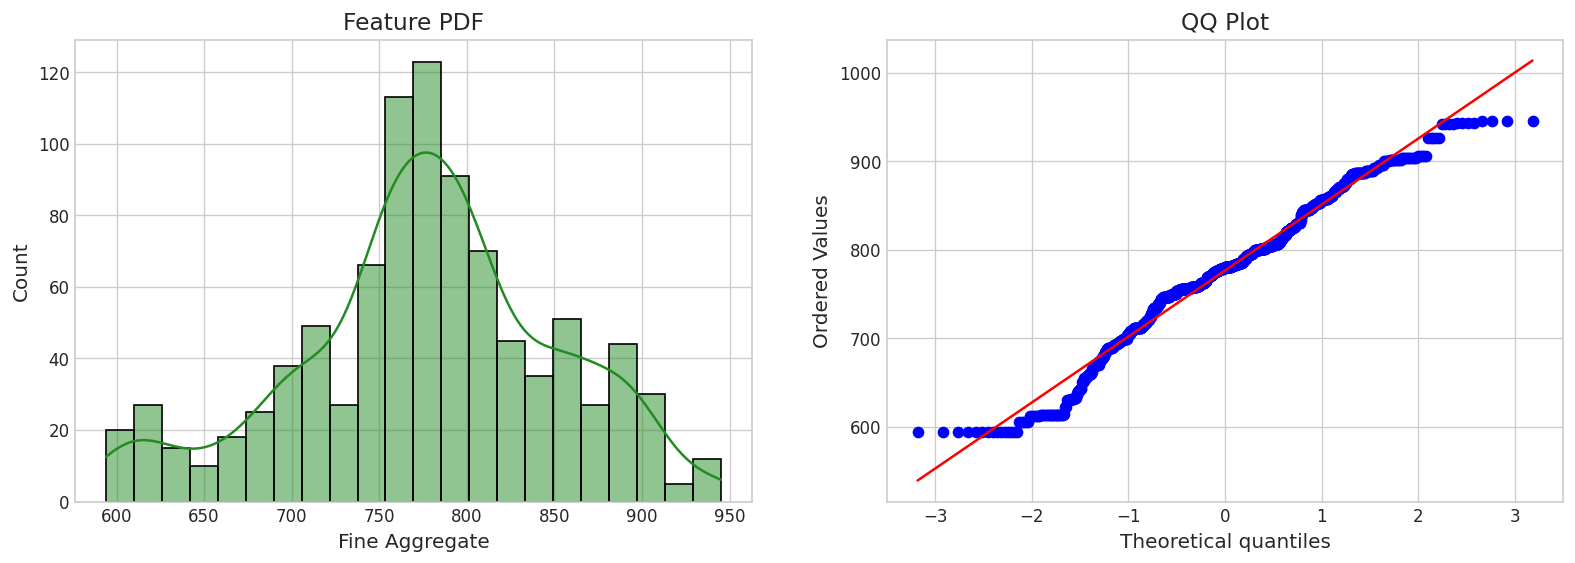

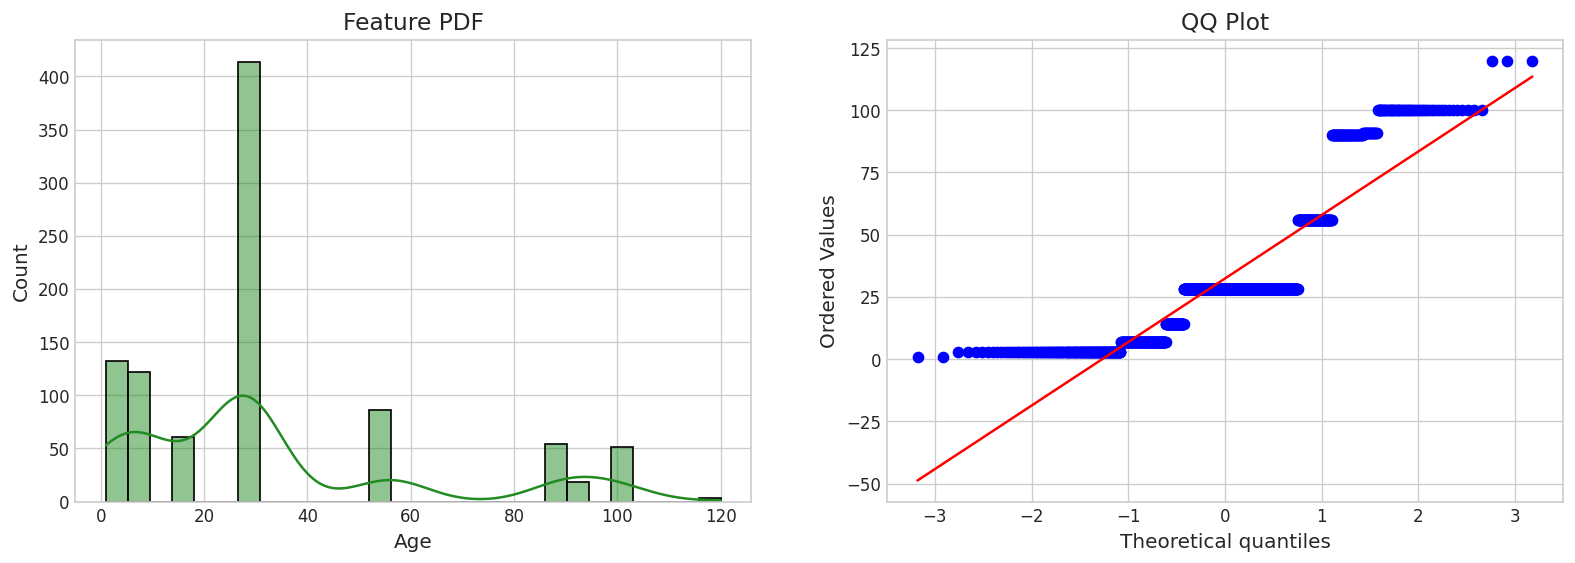

In [99]:
# Hist + KDE Along with QQ Plot to check the Normality of Features
import scipy.stats as stats

for col in X.columns:
    plt.figure(figsize=(16,5))
    plt.subplot(121)
    sns.histplot(X[col] , kde=True,color='forestgreen')
    plt.title('Feature PDF')
    plt.subplot(122)
    stats.probplot(X[col] , dist='norm' , plot=plt)
    plt.title('QQ Plot')
    plt.show()

- Cement, Water, Coarse Aggregate, Fine Aggregate Features are sort of Normal
- Age, SuperPlasticizer and Fly Ash Features are not all at Normal and It is heavily right skewed

### ***Bivariate Analysis***

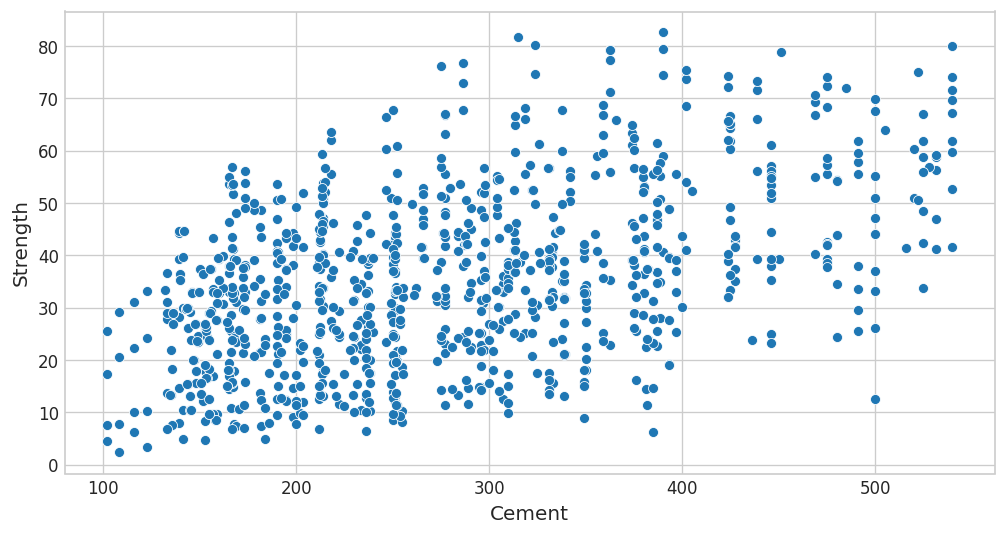

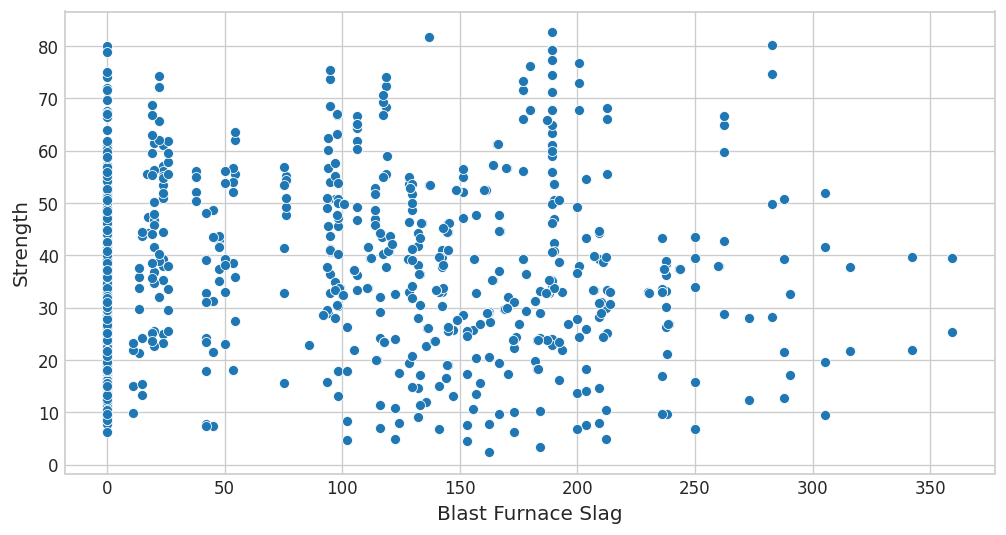

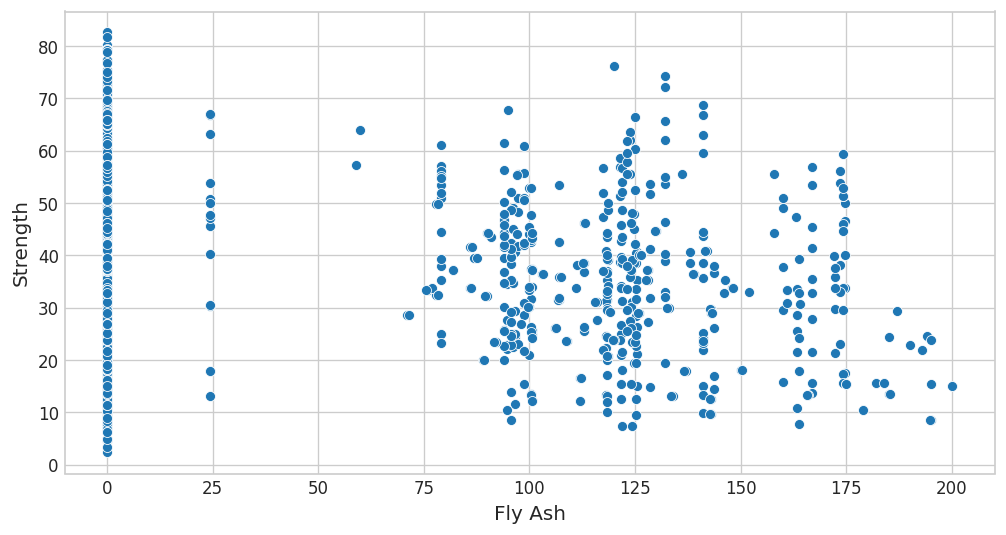

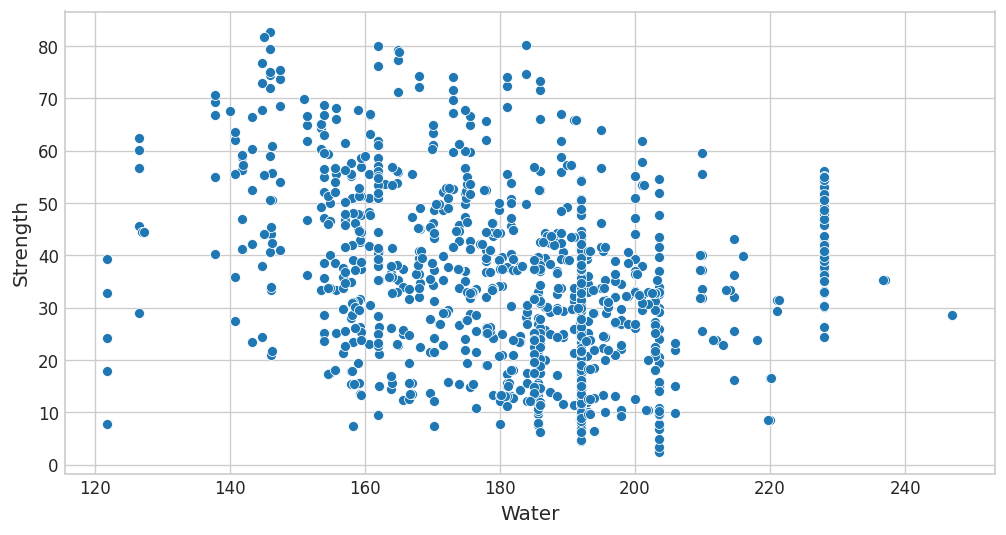

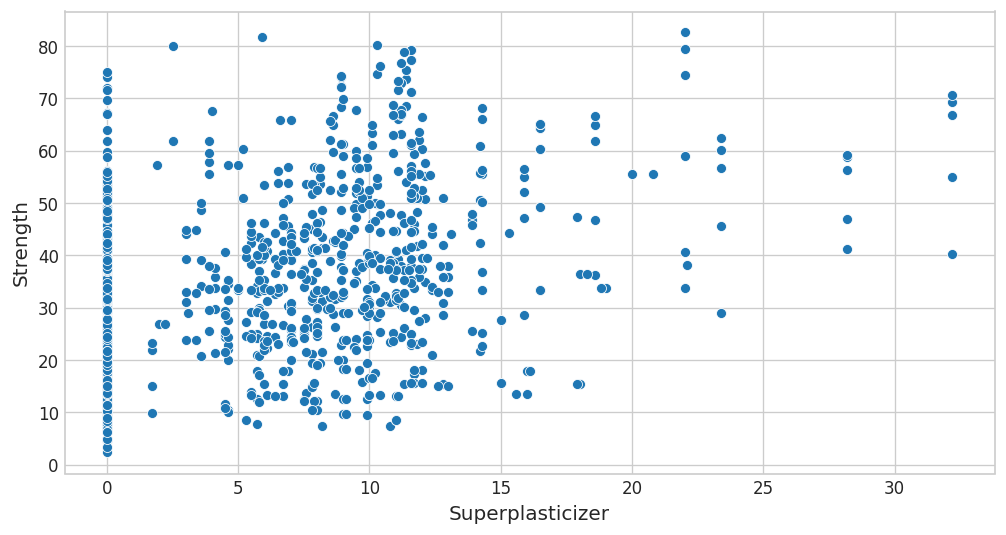

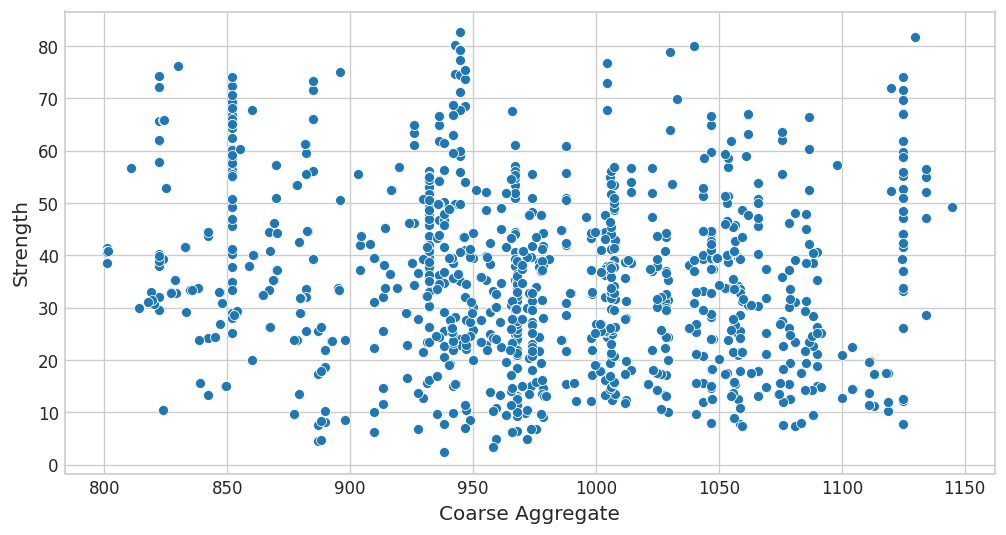

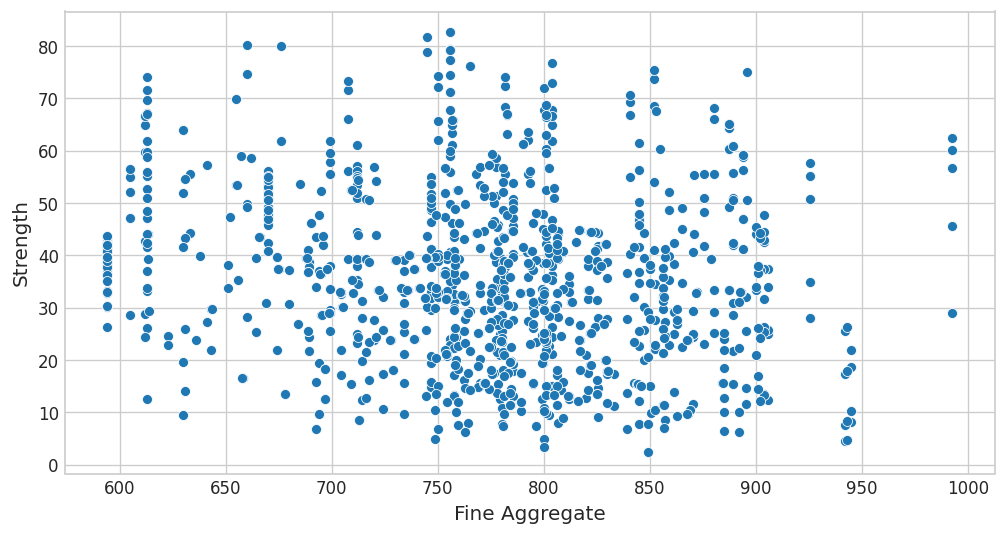

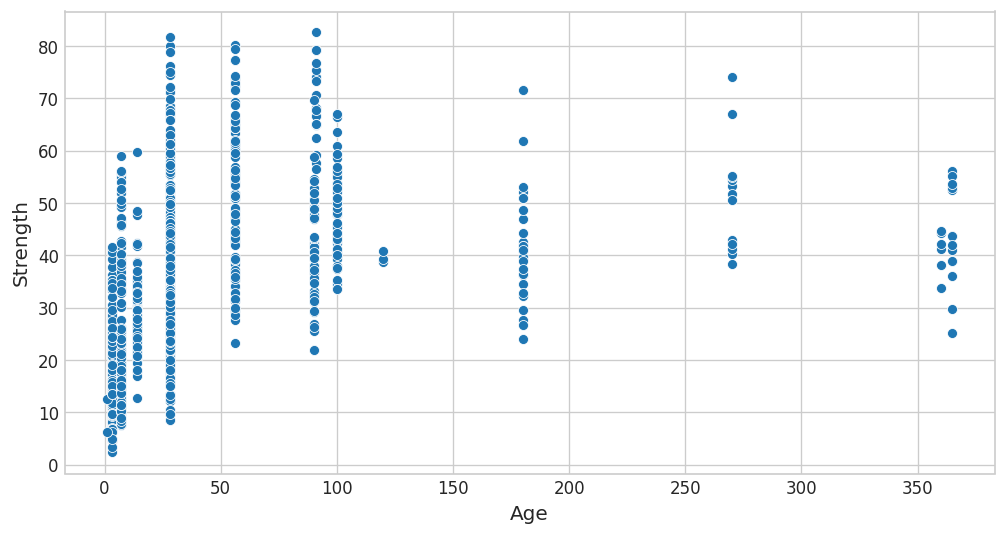

In [18]:
for col in X.columns:
    plt.figure(figsize=(10,5))
    sns.scatterplot(x = X[col],y=y)
    plt.show()

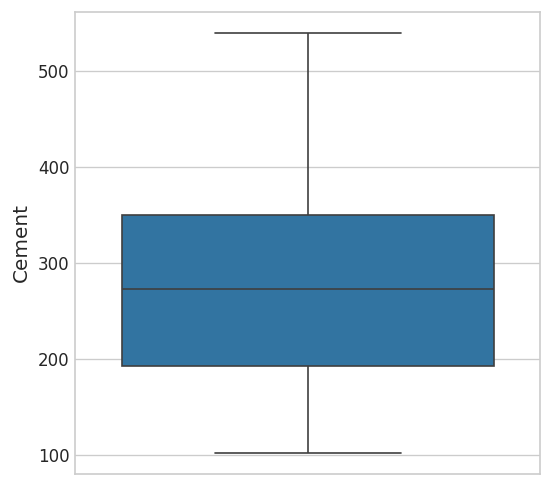

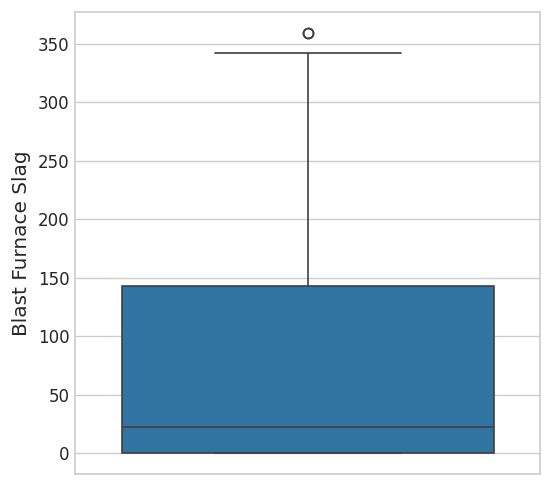

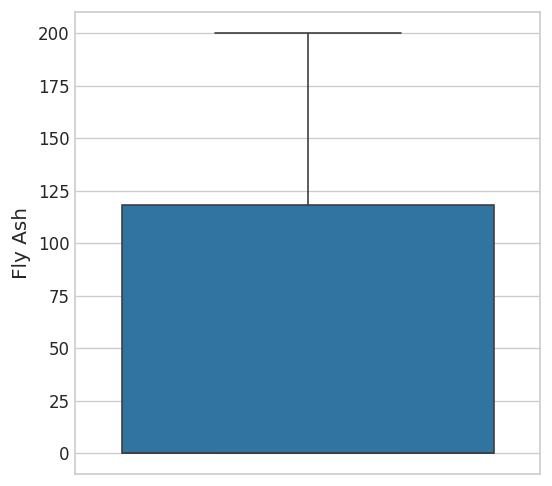

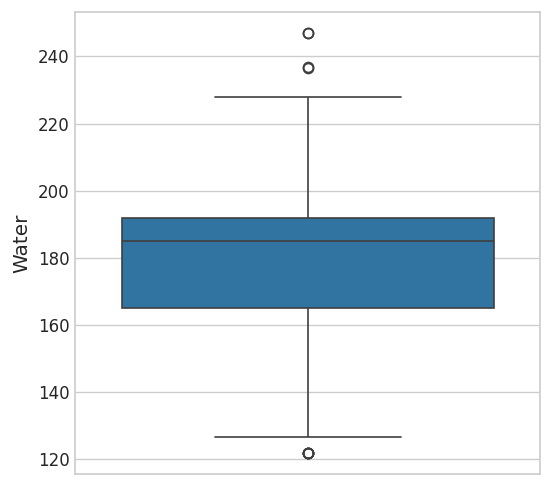

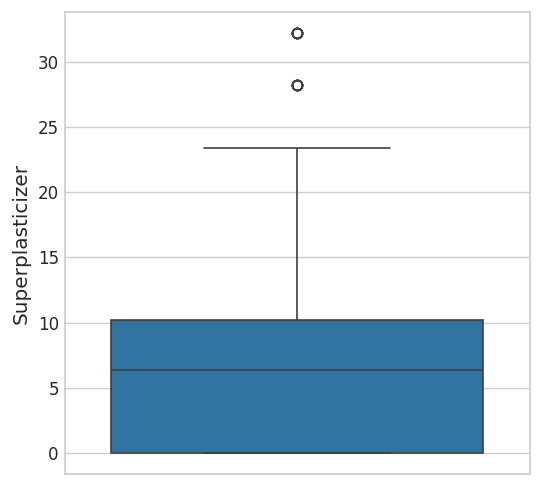

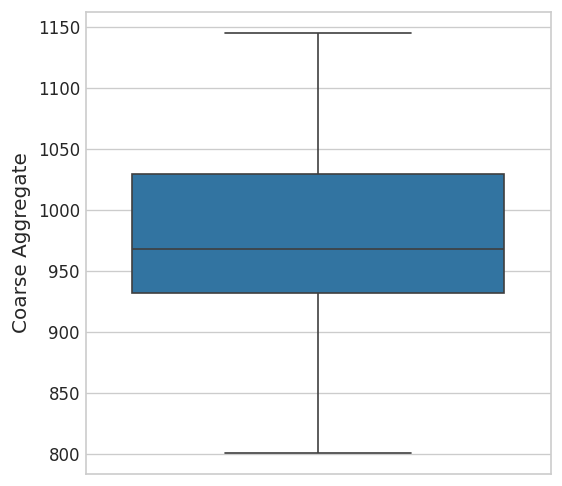

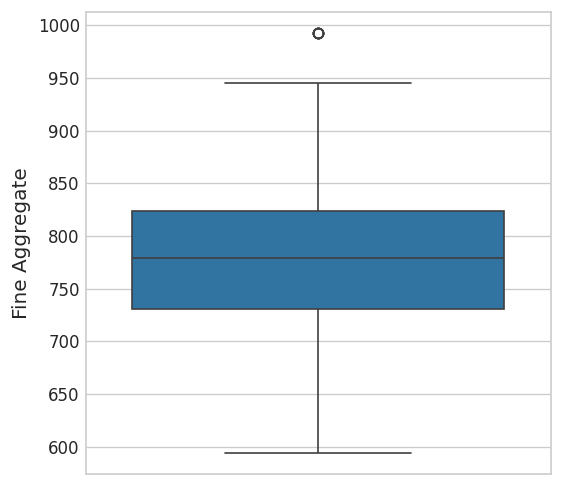

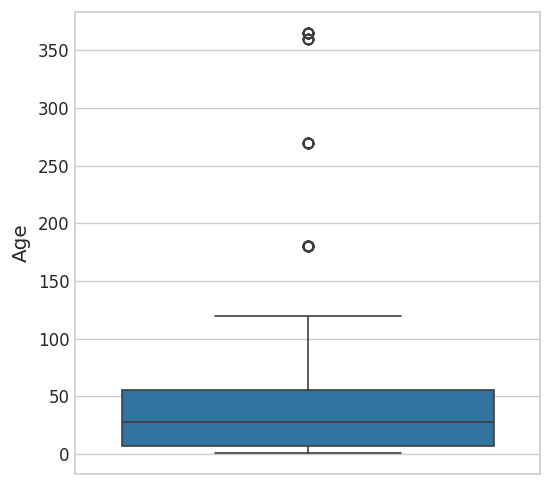

In [86]:
for col in X.columns:
    plt.figure(figsize=(5,5))
    sns.boxplot(X[col])
    plt.show()

### ***Multivariate***

<Axes: >

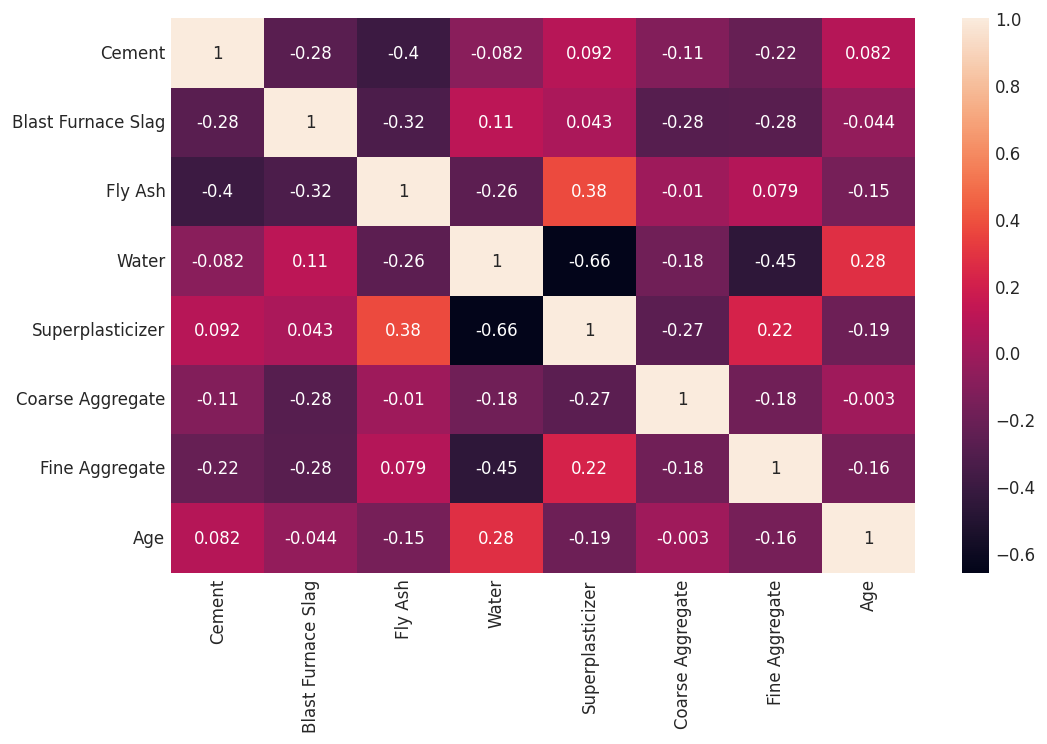

In [19]:
sns.heatmap(X.corr(), annot=True)

### **Model Linear Regression Without Scaling and Transforming the data**

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [ ]:
import pandas as pd
import numpy as np


SyntaxError: invalid syntax (1556452855.py, line 1)

In [67]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2)
lr = LinearRegression()
model = lr.fit(X_train,y_train)
y_pred = model.predict(X_test)

print(f"R2 -> {r2_score(y_test , y_pred)}")

R2 -> 0.6280306885391791


### ***Cross Validation***

In [68]:
cross_val = (np.mean(cross_val_score(lr , X,y , cv=10 , scoring='r2'))) # This is so BAD !!!
print(cross_val) 

0.27820729160873764


### ***Power Transforming***

### (i) Box-Cox Method

In [69]:
tnf = PowerTransformer(method='box-cox')
tnf.set_output(transform='pandas')

X_train_tnf = tnf.fit_transform(X_train+0.001)
X_test_tnf = tnf.transform(X_test+0.001)


### ***Histplot + QQ Plot***

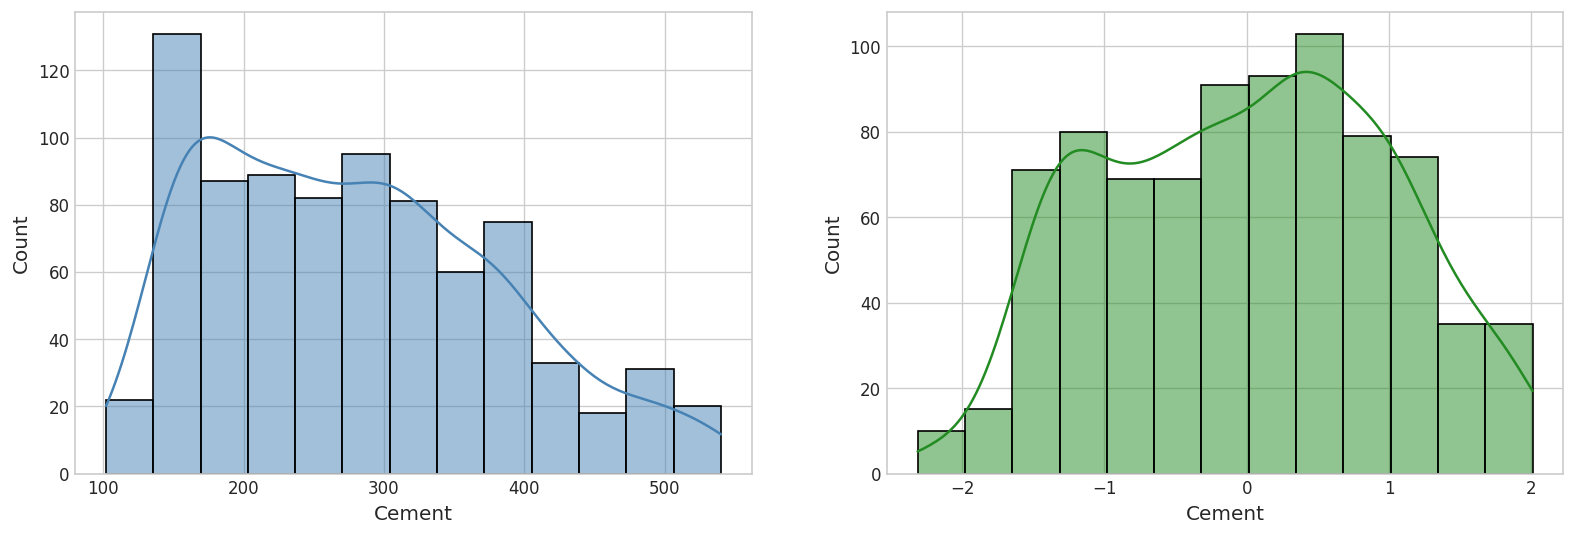

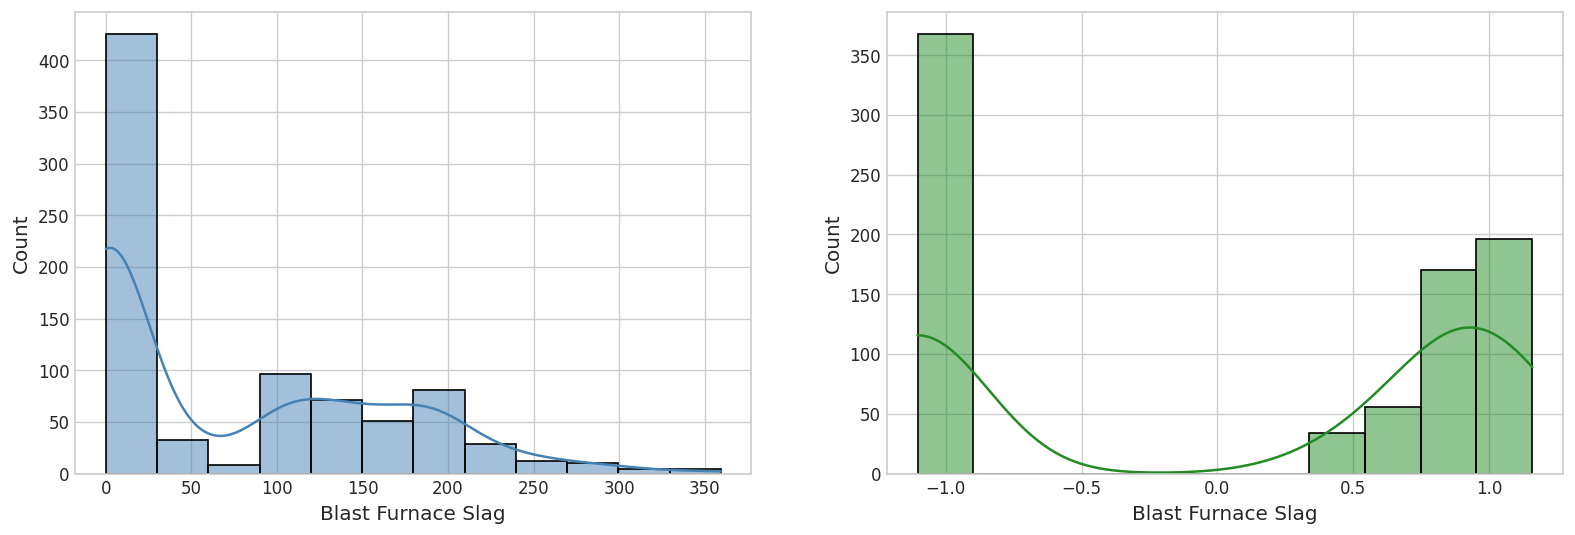

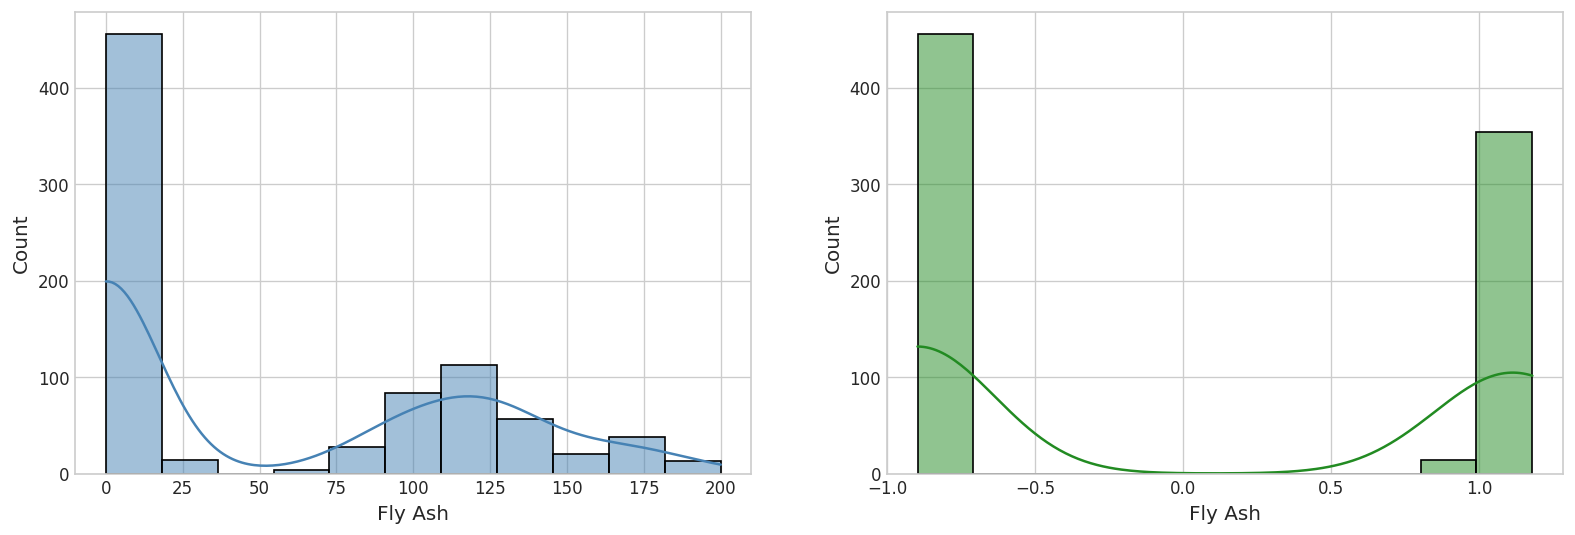

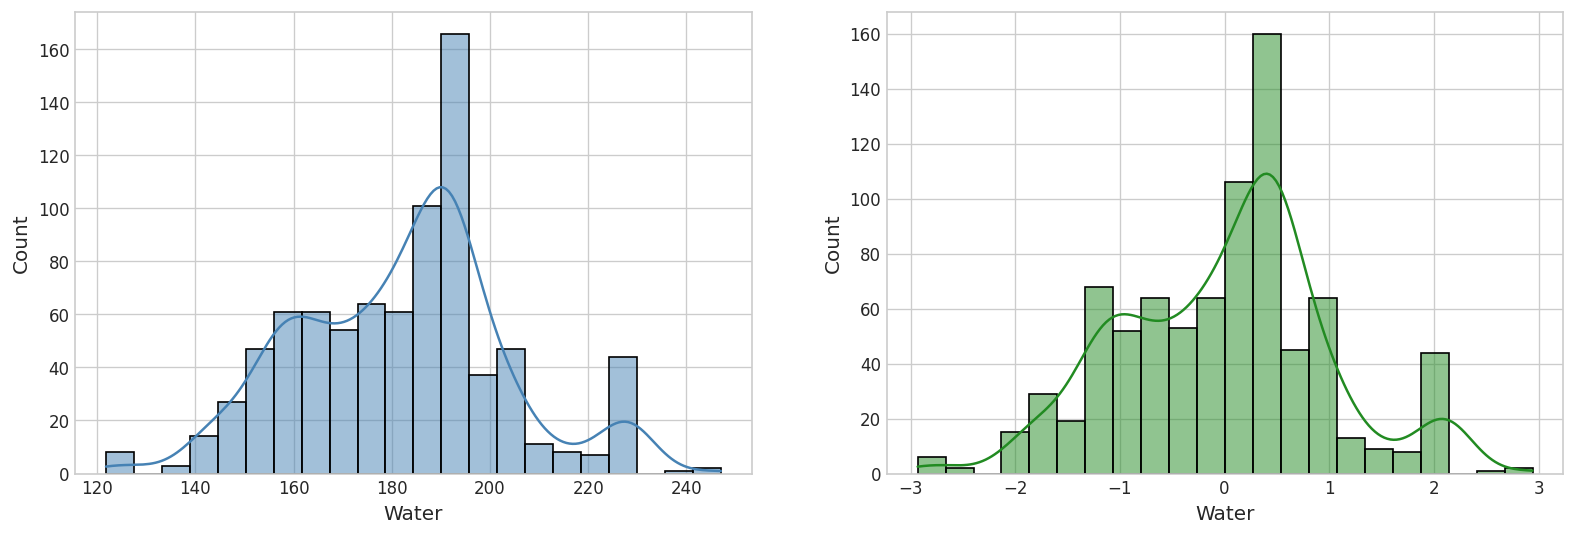

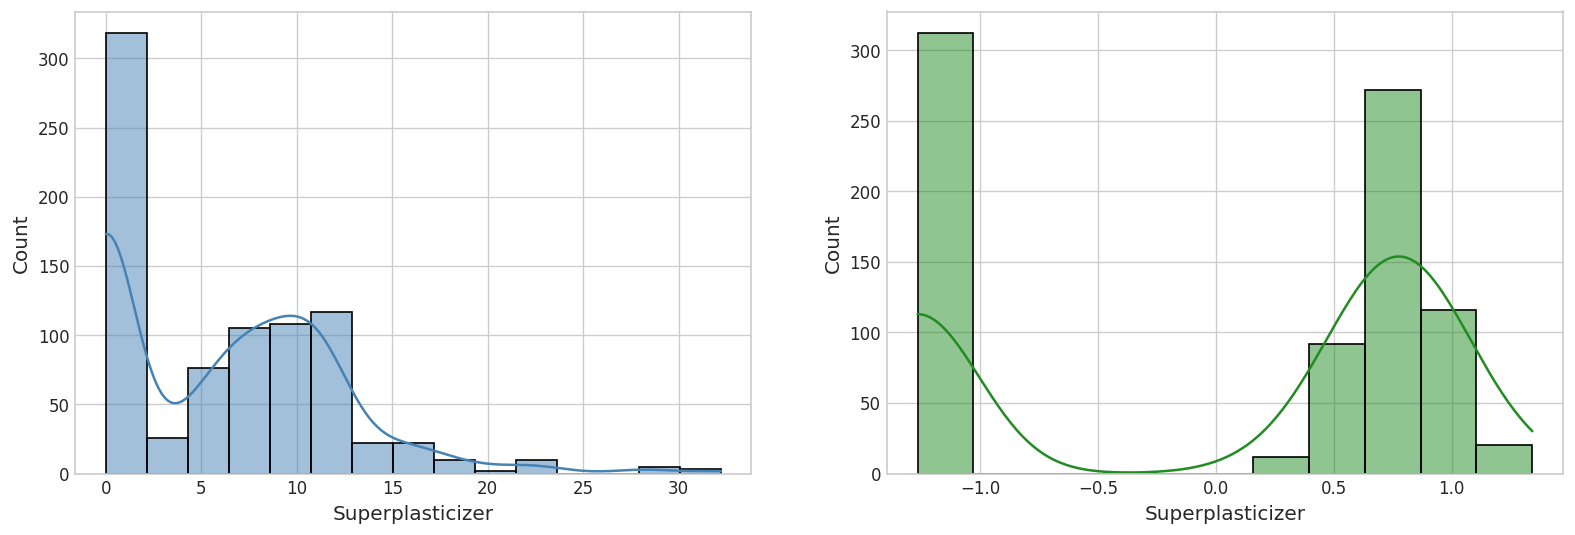

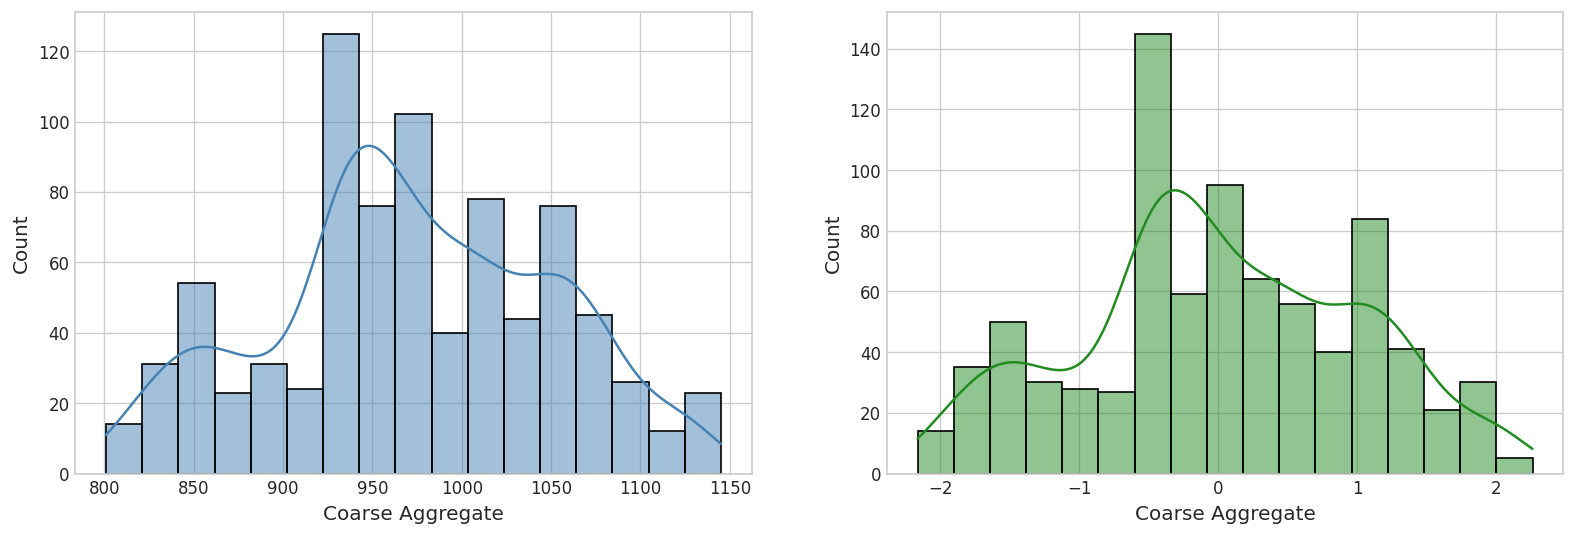

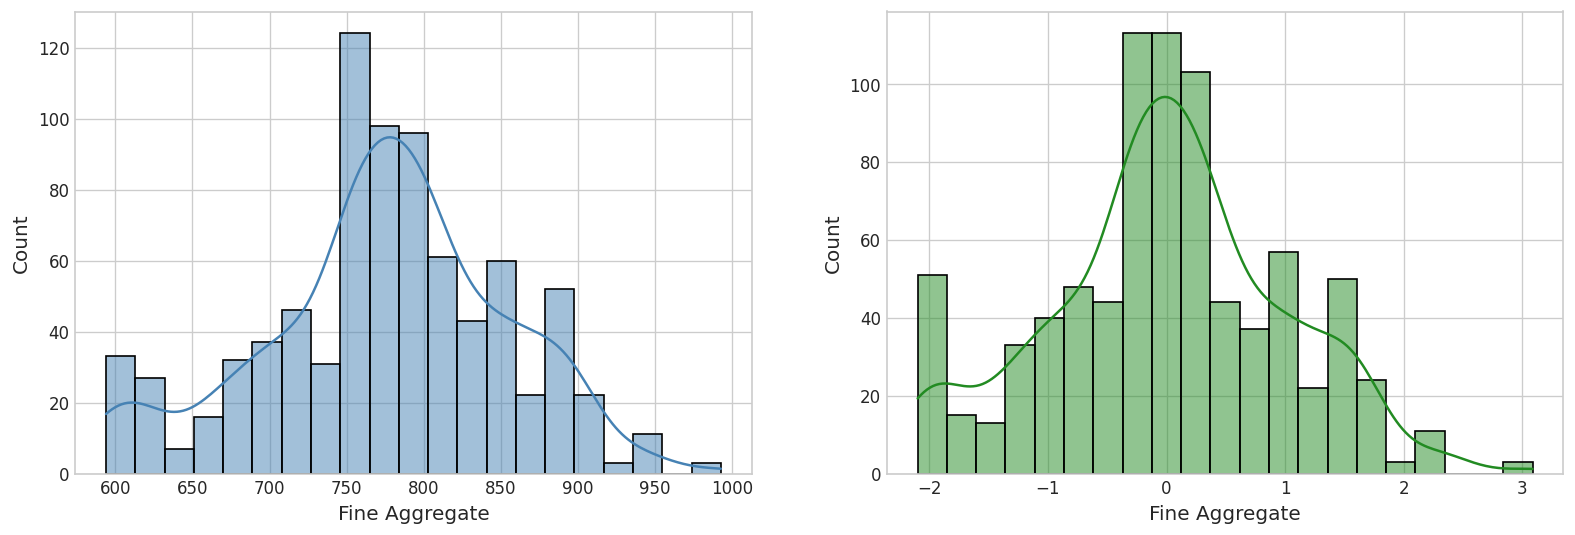

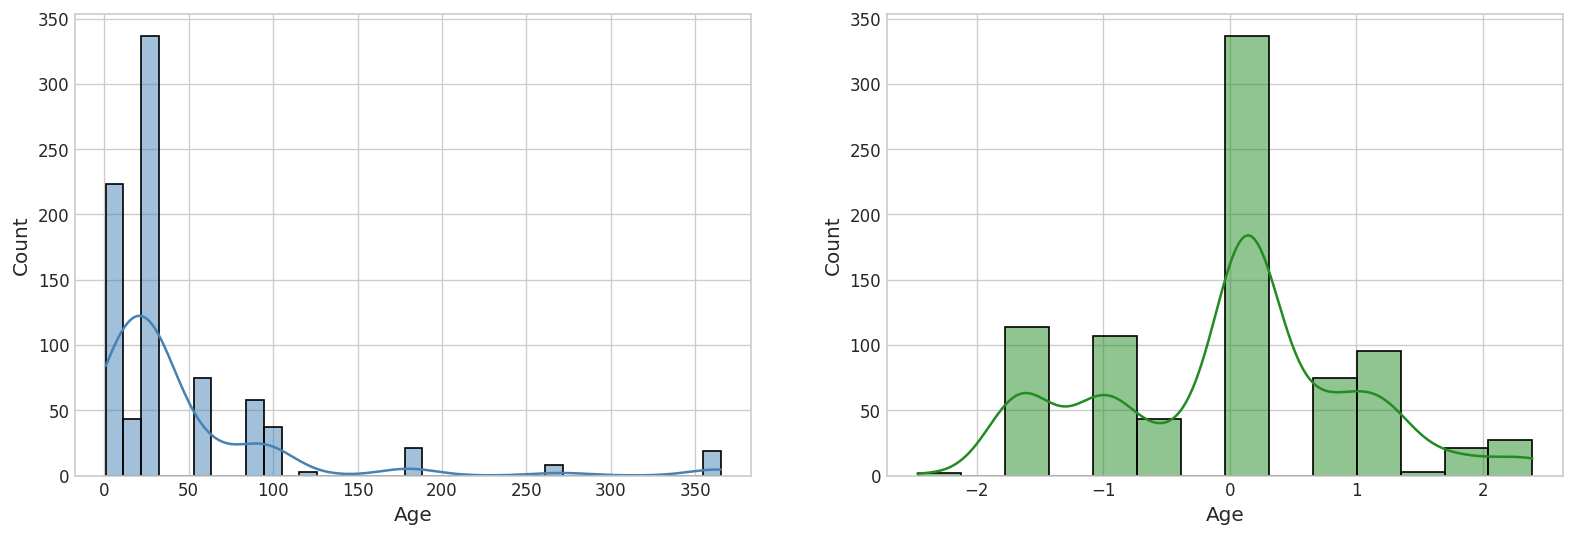

In [71]:
for col in X_train_tnf:
    plt.figure(figsize=(16,5))
    plt.subplot(121)
    sns.histplot(X_train[col] , color='steelblue', kde=True)
    plt.subplot(122)
    sns.histplot(X_train_tnf[col], color='forestgreen',kde=True)
    plt.show()

In [72]:
# The values of lambdas for each column
pd.DataFrame({'cols':X_train.columns , 'lambdas': tnf.lambdas_} , columns = ['cols','lambdas'])

,cols,lambdas
0,Cement,0.170274
1,Blast Furnace Slag,0.044888
2,Fly Ash,-0.056232
3,Water,0.739487
4,Superplasticizer,0.148944
5,Coarse Aggregate,1.198563
6,Fine Aggregate,1.903428
7,Age,0.038519


### ***Model Training After Box Cox Transform***

In [73]:
lr1 = LinearRegression()
model = lr1.fit(X_train_tnf , y_train)
y_pred_tnf = model.predict(X_test_tnf)

print(f'R2 -> {r2_score(y_test , y_pred_tnf)}')

R2 -> 0.7865117790782231


### ***Cross Validation***

In [74]:
X_tnf = tnf.transform(X+0.001)
tnf.set_output(transform='pandas')
cross_val_box = cross_val_score(lr1 , X_tnf , y , cv=10 , scoring='r2').mean()
print(cross_val_box)

0.6510680154378117


- Now this is called an Improvement. From 27.8% to 64.9% Nice!!

### ***Using Yeo-Johnson Transform***

In [75]:
tnf2 = PowerTransformer(method='yeo-johnson')
tnf2.set_output(transform='pandas')
X_train_tnf2 = tnf2.fit_transform(X_train)
X_test_tnf2 = tnf2.transform(X_test)

### ***Plotting the Changes b/w Box Cox and Yeo Johnson***

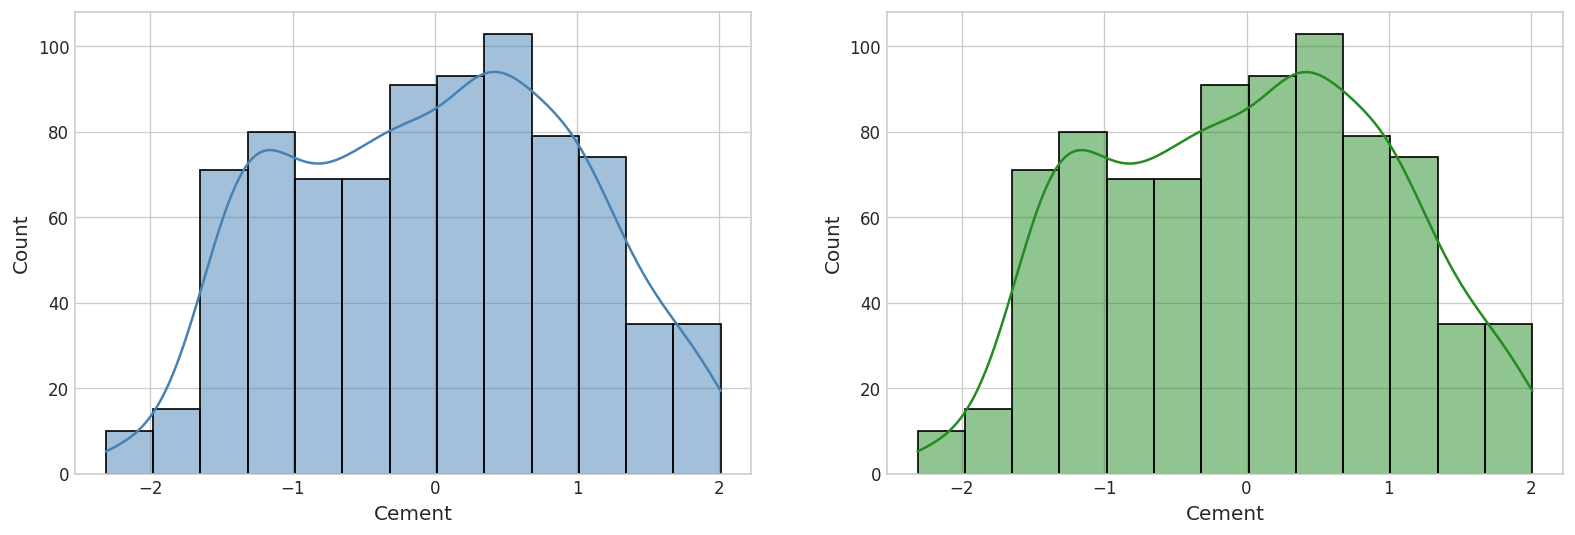

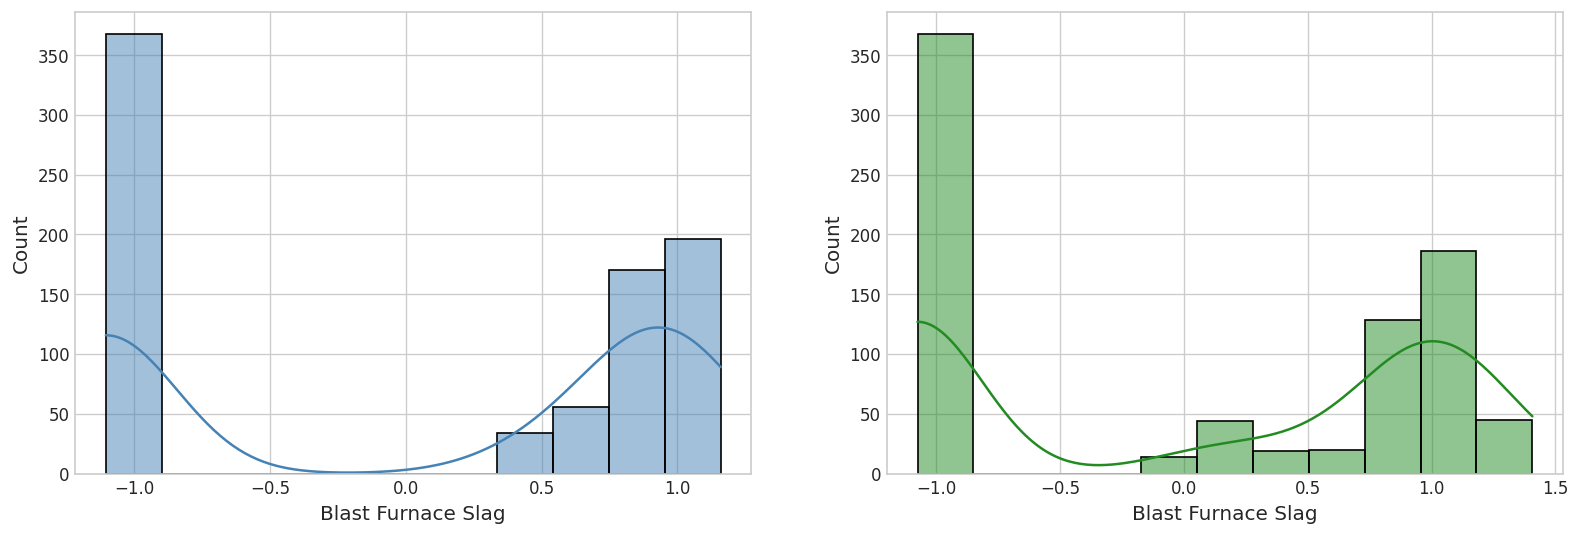

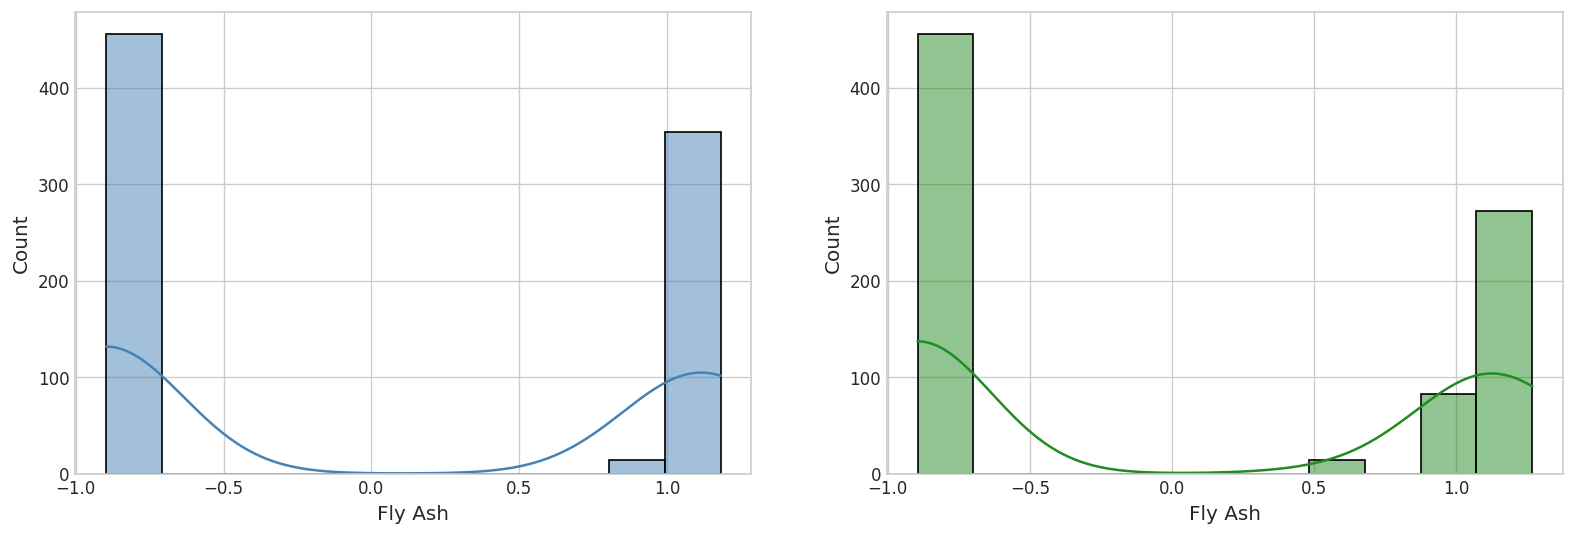

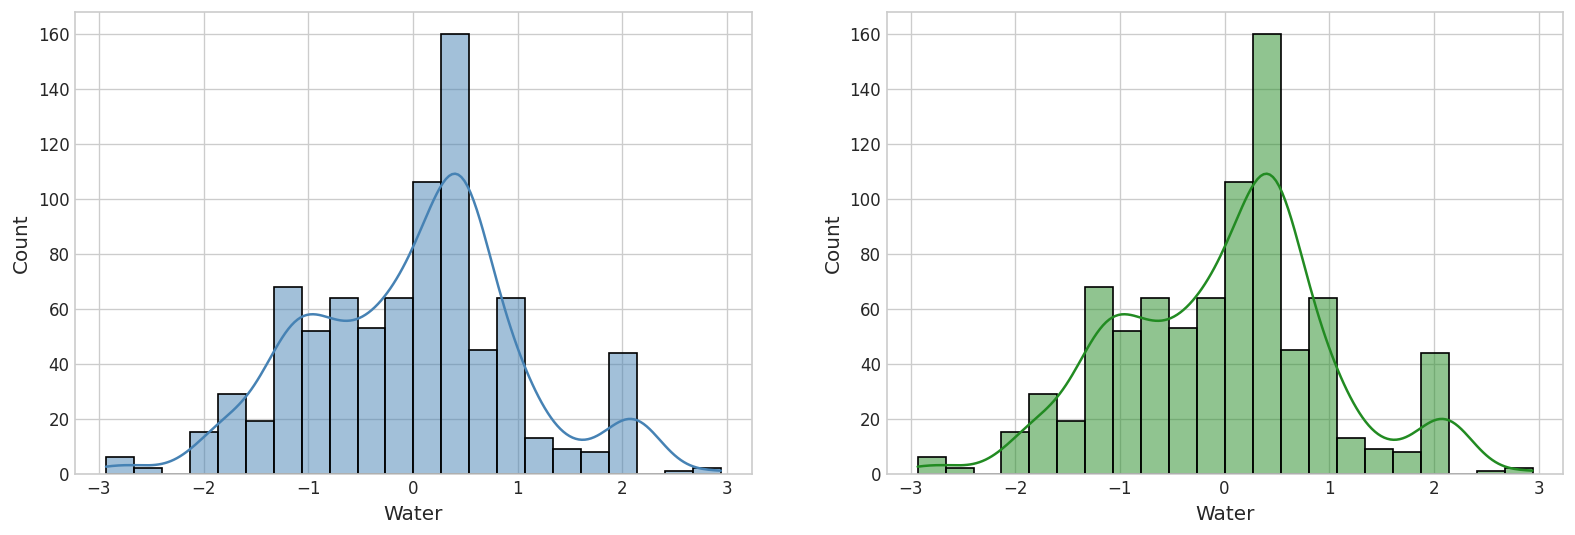

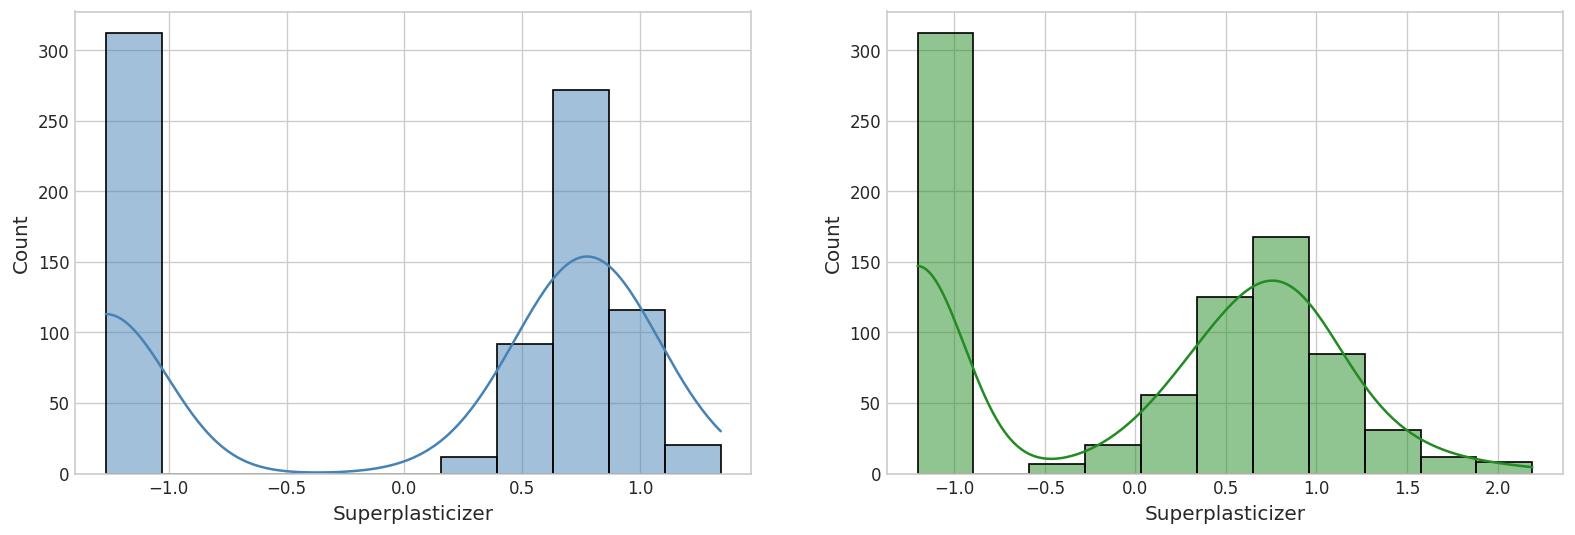

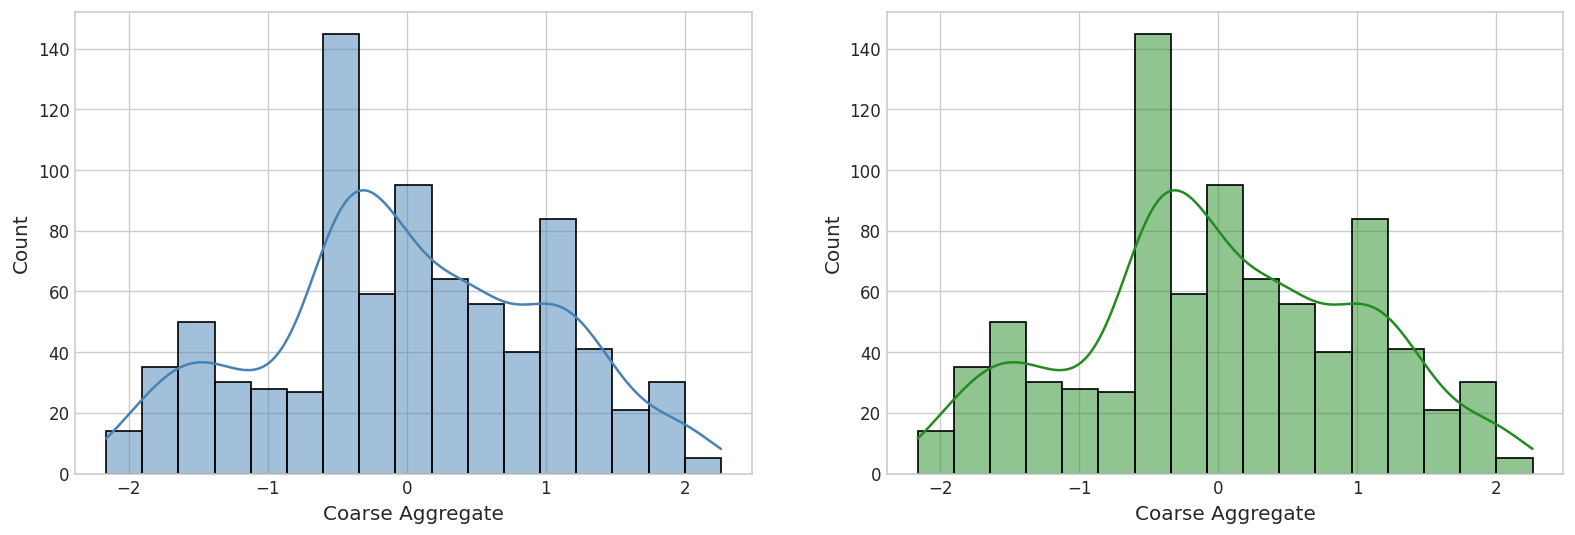

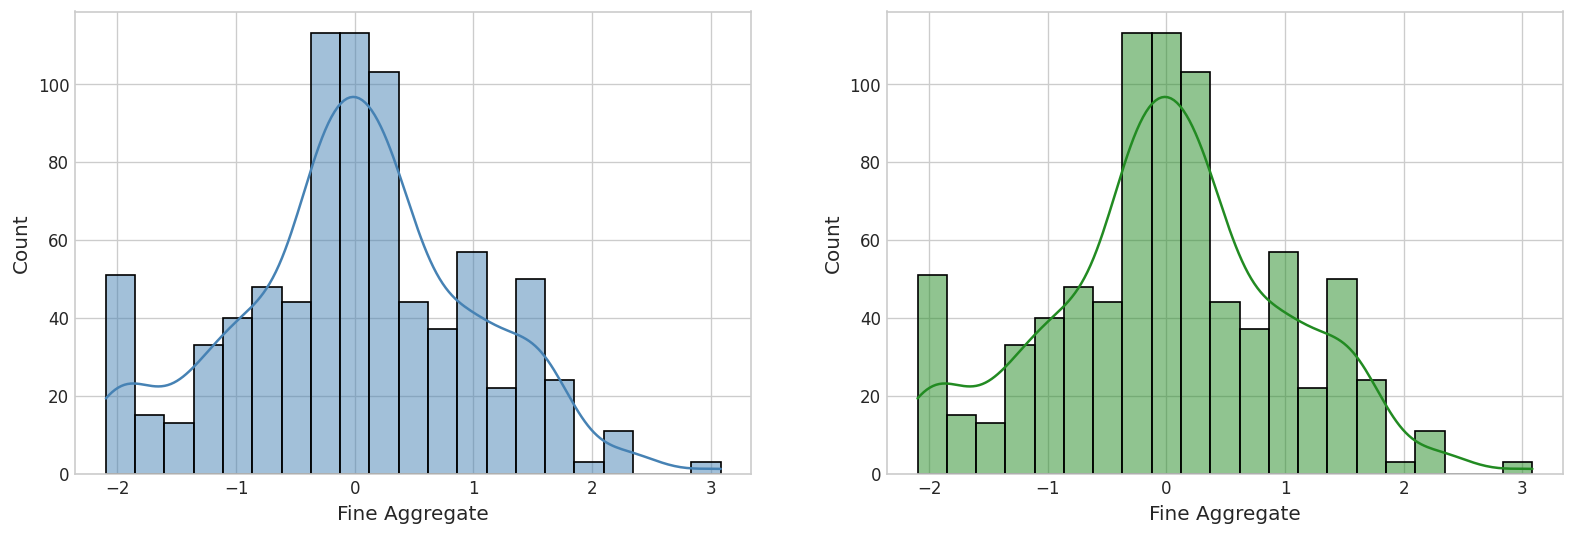

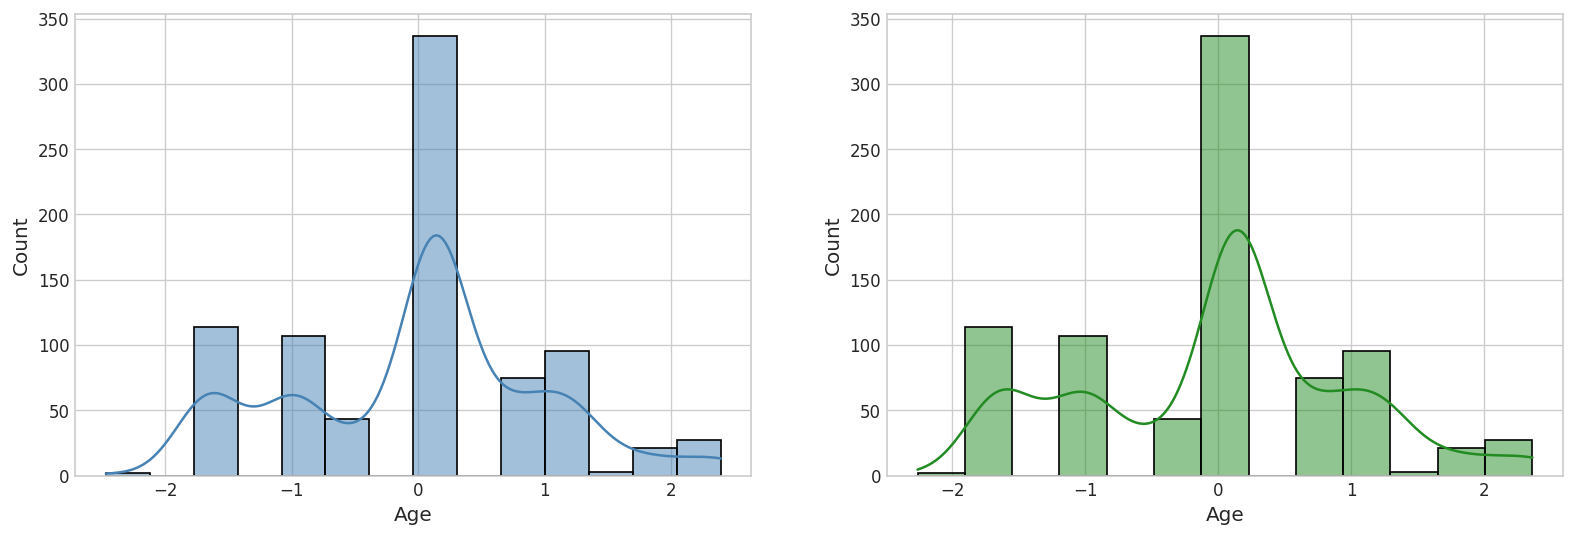

In [76]:
for col in X_train_tnf:
    plt.figure(figsize=(16,5))
    plt.subplot(121)
    sns.histplot(X_train_tnf[col] , color='steelblue', kde=True)
    plt.subplot(122)
    sns.histplot(X_train_tnf2[col], color='forestgreen',kde=True)
    plt.show()

In [77]:
#Values of Lambdas
pd.DataFrame({'cols':X_train_tnf2.columns , 'lambdas-yeo':tnf2.lambdas_})

,cols,lambdas-yeo
0,Cement,0.167557
1,Blast Furnace Slag,0.034941
2,Fly Ash,-0.147042
3,Water,0.738004
4,Superplasticizer,0.231186
5,Coarse Aggregate,1.198868
6,Fine Aggregate,1.904663
7,Age,-0.009393


### ***Model Fitting and Cross Validation Results***

In [80]:
lr = LinearRegression()
model = lr.fit(X_train_tnf2 , y_train)
y_pred_tnf2 = model.predict(X_test_tnf2)

# ---------- Comparing All the Modelling ------------
print(f'R2-Score Without Transform ->\n{r2_score(y_test,y_pred)}')
print(f'R2-Score With Box-Cox Transform ->\n{r2_score(y_test,y_pred_tnf)}')
print(f'R2-Score With Yeo-Johnson Transform ->\n{r2_score(y_test,y_pred_tnf2)}')

R2-Score Without Transform ->
0.6280306885391791
R2-Score With Box-Cox Transform ->
0.7865117790782231
R2-Score With Yeo-Johnson Transform ->
0.7859932492566506


### ***Cross-Validation Comparison***

In [81]:
X_tnf2 = tnf2.fit_transform(X)
# tnf2.set_output(transform='pandas')

cross_val_yeo = np.mean(cross_val_score(lr , X_tnf2 , y , cv=10 , scoring='r2'))
# print(cross_val_yeo)

print(f'CV Without Transform -> {cross_val}')
print(f'CV With Box-Cox Transform -> {cross_val_box}')
print(f'CV With Yeo-Johnson Transform -> {cross_val_yeo}')

CV Without Transform -> 0.27820729160873764
CV With Box-Cox Transform -> 0.6510680154378117
CV With Yeo-Johnson Transform -> 0.6586548619389644


### ***Removing The Outliers***

In [93]:
import pandas as pd
import numpy as np

def remove_all_outliers(df, multiplier=1.5):
    df = df.copy()
    df.columns = df.columns.str.strip()          # fix whitespace in column names
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Build one combined mask across all columns
    combined_mask = pd.Series(True, index=df.index)  # start: keep all rows
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        
        col_mask = (df[col] >= lower) & (df[col] <= upper)
        outlier_count = (~col_mask).sum()
        
        print(f"{col:<30} | bounds [{lower:.2f}, {upper:.2f}] | outliers: {outlier_count}")
        
        combined_mask &= col_mask  # AND — row kept only if clean in ALL columns
    
    df_clean = df[combined_mask]
    print(f"\nOriginal: {len(df)} rows → After removal: {len(df_clean)} rows "
          f"({len(df) - len(df_clean)} removed)")
    
    return df_clean


df = pd.read_csv('concrete_data.csv')
df_cleaned = remove_all_outliers(df, multiplier=1.5)

Cement                         | bounds [-44.06, 586.44] | outliers: 0
Blast Furnace Slag             | bounds [-214.42, 357.38] | outliers: 2
Fly Ash                        | bounds [-177.45, 295.75] | outliers: 0
Water                          | bounds [124.25, 232.65] | outliers: 9
Superplasticizer               | bounds [-15.30, 25.50] | outliers: 10
Coarse Aggregate               | bounds [785.90, 1175.50] | outliers: 0
Fine Aggregate                 | bounds [591.38, 963.57] | outliers: 5
Age                            | bounds [-66.50, 129.50] | outliers: 59
Strength                       | bounds [-9.93, 79.77] | outliers: 4

Original: 1030 rows → After removal: 941 rows (89 removed)


### Now Again Using Transformation Yeo Johnson and evaluating

In [97]:
X = df_cleaned.iloc[:,:-1]
y = df_cleaned.iloc[:,-1]

lr = LinearRegression()

tnf2 = PowerTransformer()
tnf2.set_output(transform='pandas')
X_tnf2 = tnf2.fit_transform(X)
# tnf2.set_output(transform='pandas')

cross_val_yeo = np.mean(cross_val_score(lr , X_tnf2 , y , cv=10 , scoring='r2'))
# print(cross_val_yeo)
print(f'CV With Yeo-Johnson Transform -> {cross_val_yeo}')

CV With Yeo-Johnson Transform -> 0.7358895093506612


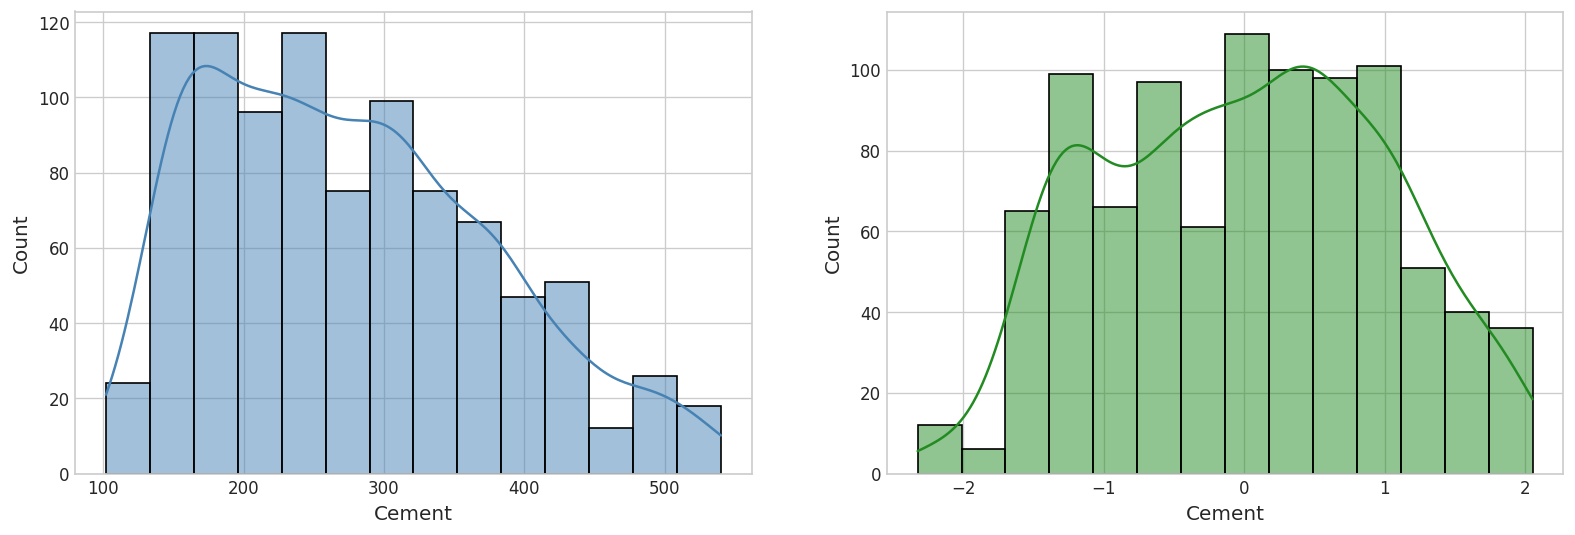

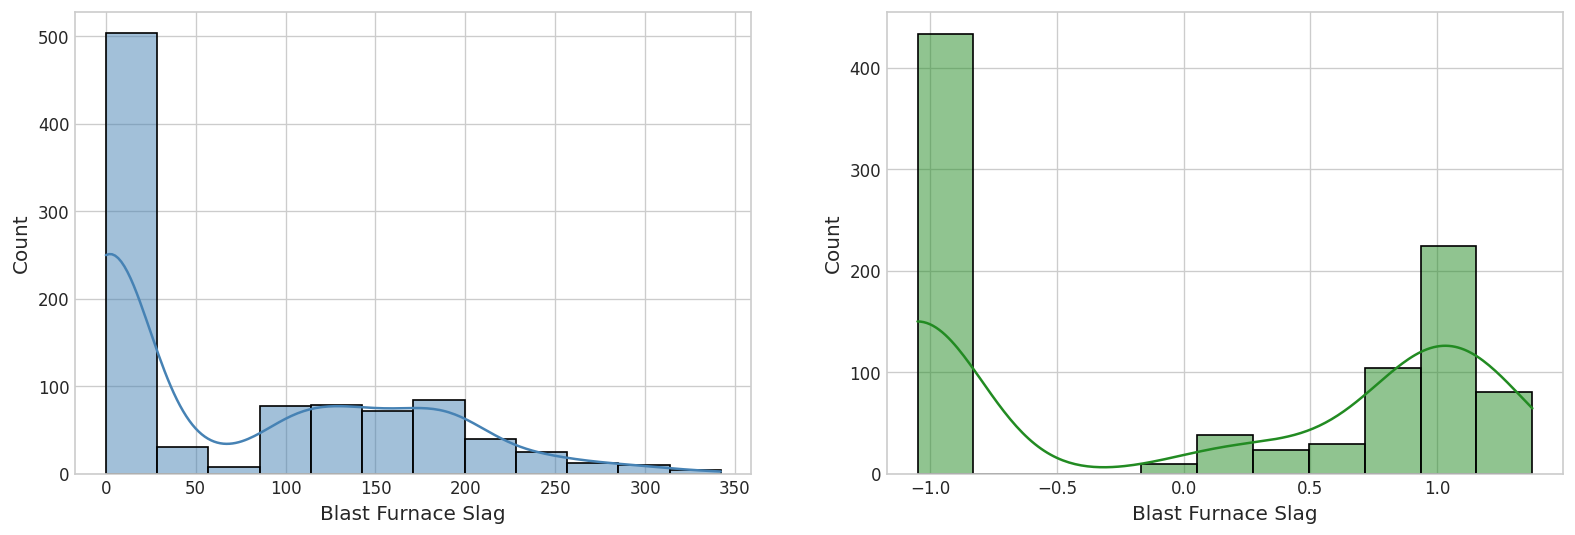

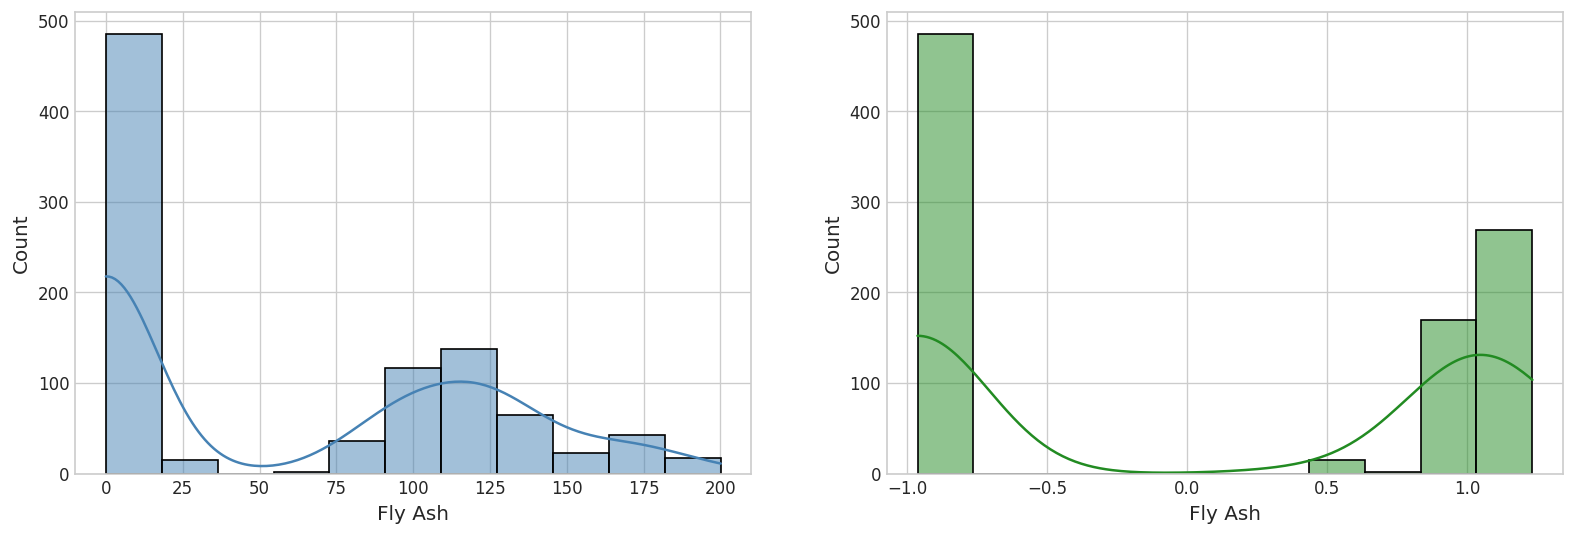

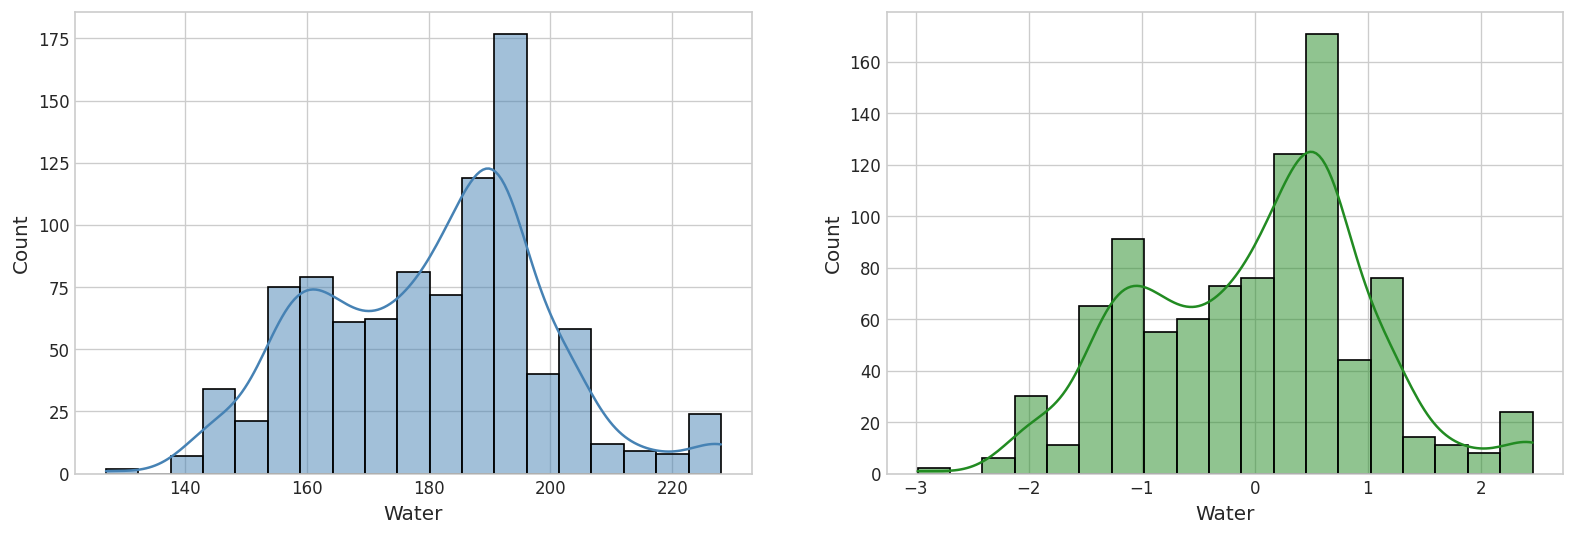

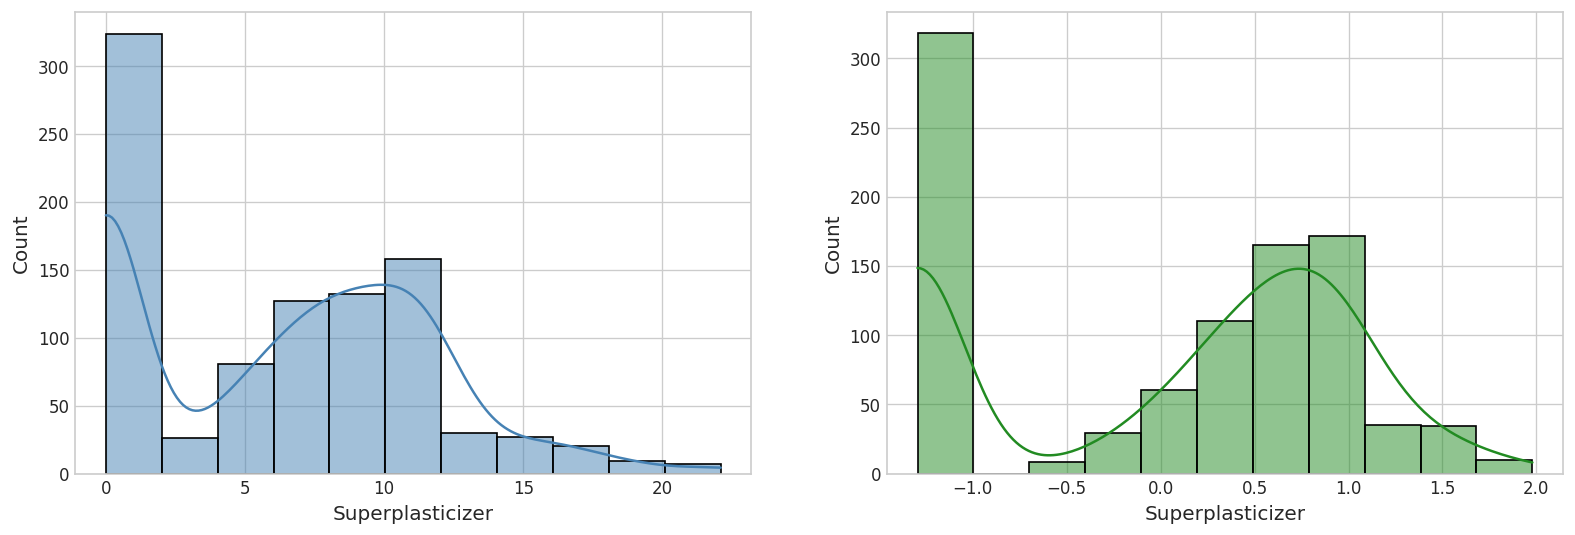

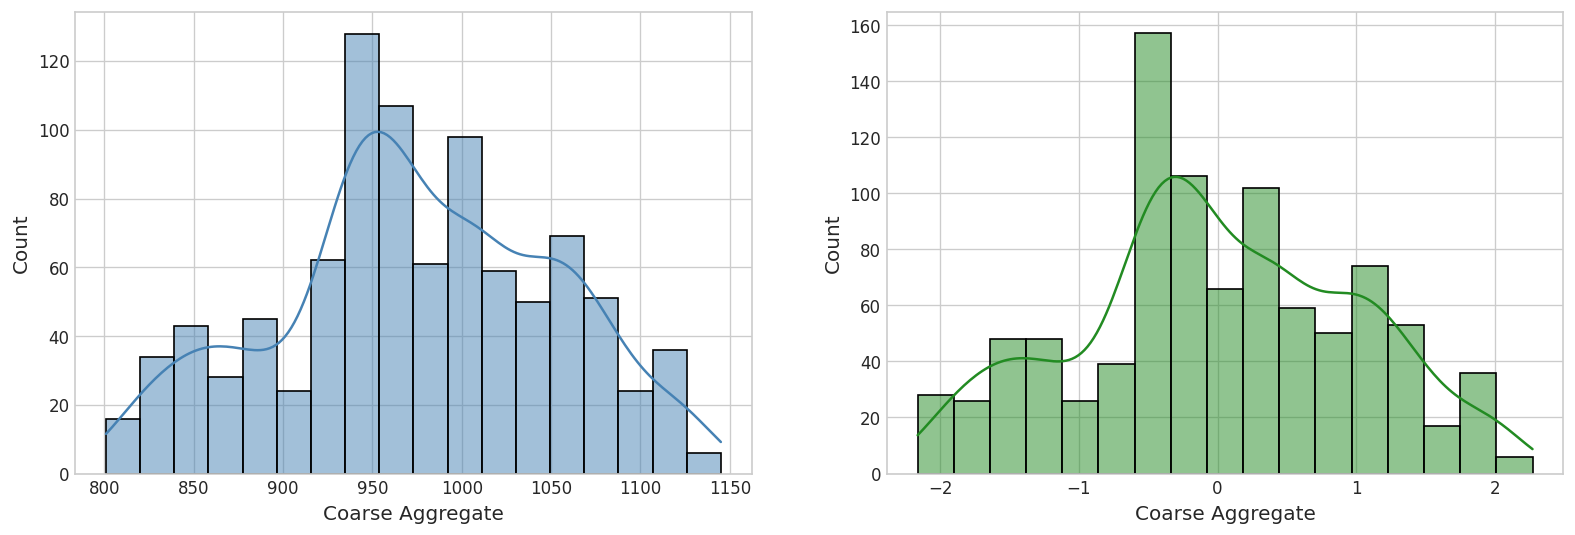

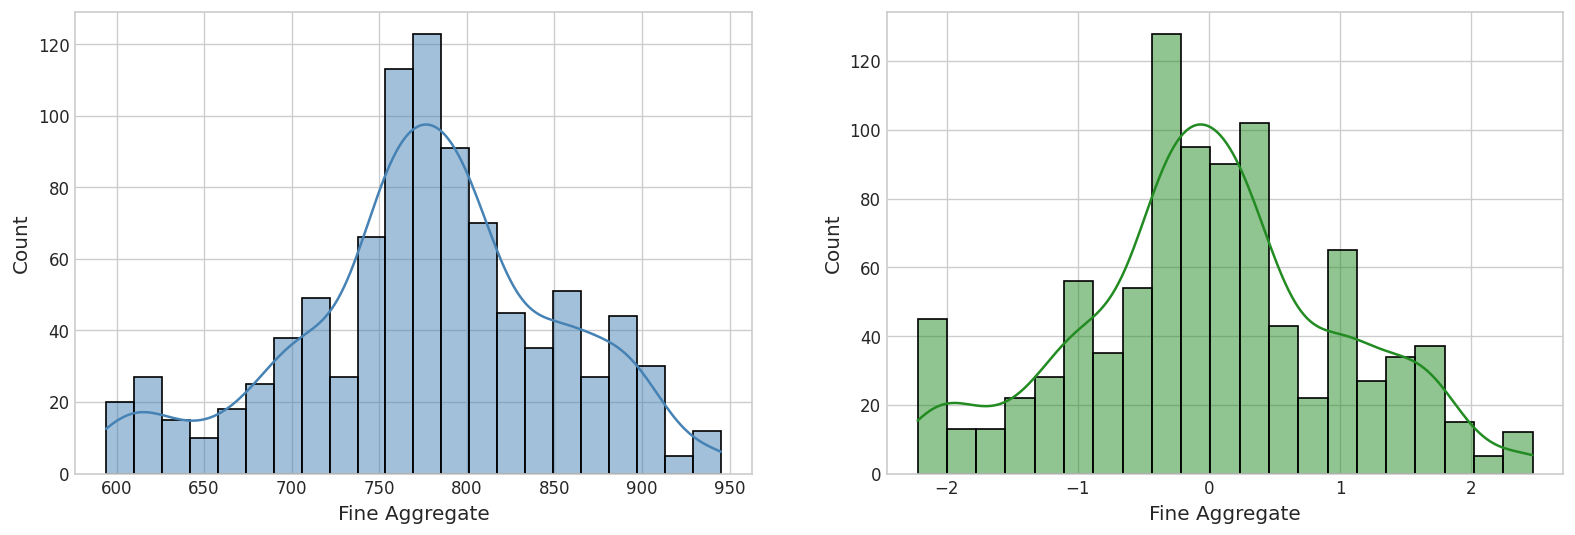

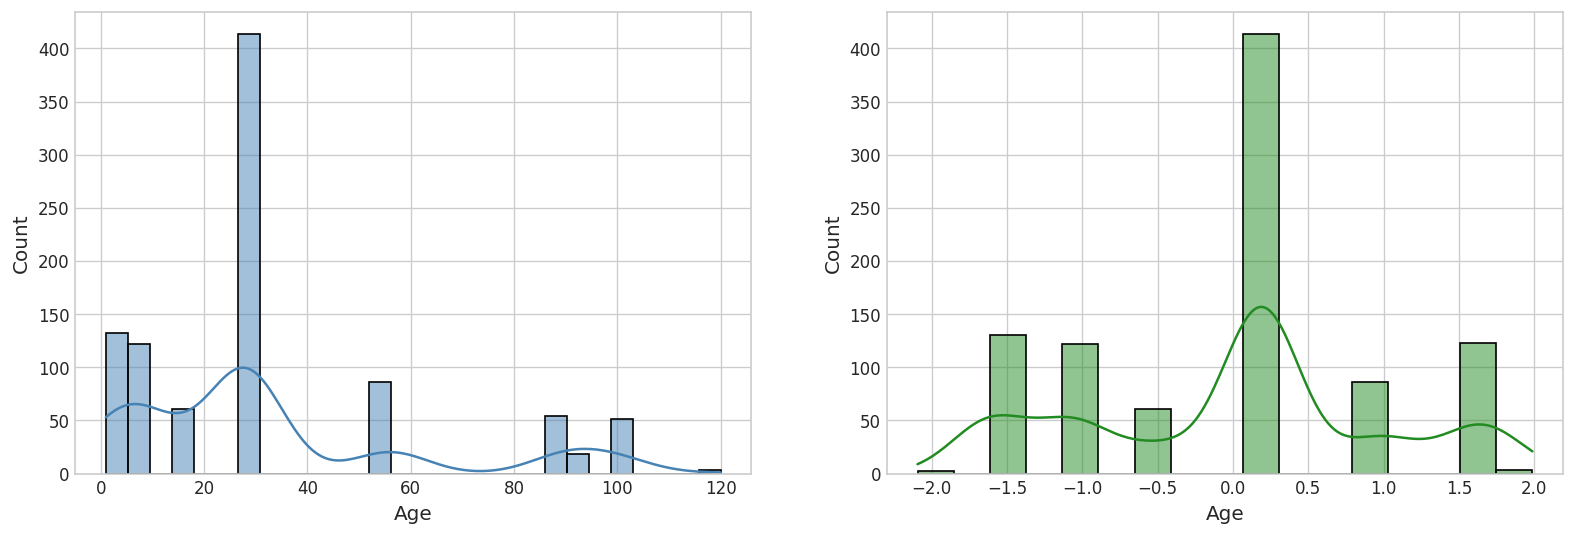

In [98]:
for col in X:
    plt.figure(figsize=(16,5))
    plt.subplot(121)
    sns.histplot(X[col] , color='steelblue', kde=True)
    plt.subplot(122)
    sns.histplot(X_tnf2[col], color='forestgreen',kde=True)
    plt.show()

- This time We saw a massive jump in the R2 Score Thus, this is the best we could get until now!!

### ***Conclusion***

- We Saw the best Model Result after Transforming The Features

### **THANK YOU!!**